# CSE422 Lab Project — Predicting Diabetes Status from Student Health Records

**Course:** CSE422 — Artificial Intelligence
**Dataset:** `7.csv` (student health-screening records)
**Target feature:** `Diabetes` (discrete, binary: `Yes` / `No`)


## 0. Setup

In [ ]:
# --- Libraries -------------------------------------------------------------
# Determinism must be requested BEFORE TensorFlow is imported, so these two
# environment variables come first. Without them, TensorFlow's op scheduling is
# non-deterministic and the neural-network results move between runs even with a
# fixed seed.
import os
os.environ["PYTHONHASHSEED"]      = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             adjusted_rand_score, silhouette_score)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["savefig.dpi"]   = 120
plt.rcParams["savefig.bbox"]  = "tight"

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

def save(name):
    """Save the current matplotlib figure into figures/ for the LaTeX report."""
    plt.savefig(os.path.join(FIGDIR, name + ".png"))

print("TensorFlow", tf.__version__)

TensorFlow 2.20.0


In [ ]:
from google.colab import drive
CSV = "7.csv"
drive.mount('/content/drive')
CSV = '/content/drive/MyDrive/CSE422/7.csv'

raw = pd.read_csv(CSV)
print("Raw shape:", raw.shape)
raw.head()

Mounted at /content/drive
Raw shape: (200000, 13)


,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
1,2.0,NaN,Male,152.069157,47.630941,B,NaN,98.714977,93.0,104.0,163.0,No,No
2,3.0,32.0,Female,182.537664,55.741083,A,16.729017,98.260293,76.0,130.0,216.0,Yes,No
3,NaN,30.0,Male,182.112867,63.332207,B,19.096042,98.839605,99.0,112.0,141.0,No,Yes
4,5.0,23.0,Female,NaN,46.234173,O,NaN,98.480008,95.0,NaN,231.0,No,No


---
## 1. Introduction

**Target feature.** We use **`Diabetes`** — a discrete, binary feature taking the values
`Yes` and `No` — as the label. The remaining twelve columns (demographics, body
measurements and vital signs) form the feature set.

**The problem.** Type-2 diabetes is very often undiagnosed in young adults, because the
condition is asymptomatic in its early stages and screening is not routine at university
age. A university health centre, however, already collects a cheap panel of measurements
at admission: age, sex, height, weight, blood type, temperature, heart rate, blood
pressure, cholesterol and smoking status. If a model could flag *which* students are
likely to be diabetic from that routine panel alone, the health centre could target its
limited confirmatory-testing budget at the highest-risk students instead of testing
everybody or nobody.

**Aim.** This project therefore asks one concrete question:

> *Do the routine measurements in this dataset carry enough information to predict a
> student's diabetes status?*

To answer it we

(i) run an exploratory analysis of the data,

(ii) build a rigorous pre-processing pipeline,

(iii) train a neural network alongside four classical
classifiers,

(iv) additionally treat the task as an unsupervised problem with k-means,
and

(v) compare everything using confusion matrices, accuracy, precision, recall, F1 and the ROC–AUC score.

**Motivation and honest framing.** A screening model is only useful if it beats the
trivial "test nobody" rule. Because only about 10 % of the students in this dataset are
diabetic, a model that answers `No` for everyone already scores 90 % accuracy while being
completely worthless. A central part of this project is therefore *methodological*: we
show why accuracy alone must never be trusted on an imbalanced problem, and we use
ROC–AUC — which is insensitive to the class prior — as the metric that actually decides
whether the models learned anything. As will be seen, the answer for this particular
dataset is a clear and defensible **no**, and Section 7 provides a positive control that
proves this is a property of the *data* rather than a bug in the pipeline.

---
## 2. Dataset Description

In [ ]:
print("Number of data points (rows) :", raw.shape[0])
print("Number of features (columns) :", raw.shape[1])
print()
raw.info()

Number of data points (rows) : 200000
Number of features (columns) : 13

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Student ID      180000 non-null  float64
 1   Age             180000 non-null  float64
 2   Gender          180000 non-null  object 
 3   Height          180000 non-null  float64
 4   Weight          180000 non-null  float64
 5   Blood Type      180000 non-null  object 
 6   BMI             180000 non-null  float64
 7   Temperature     180000 non-null  float64
 8   Heart Rate      180000 non-null  float64
 9   Blood Pressure  180000 non-null  float64
 10  Cholesterol     180000 non-null  float64
 11  Diabetes        180000 non-null  object 
 12  Smoking         180000 non-null  object 
dtypes: float64(9), object(4)
memory usage: 19.8+ MB


In [ ]:
# Classify every column as quantitative or categorical
desc = pd.DataFrame({
    "dtype"     : raw.dtypes.astype(str),
    "n_unique"  : raw.nunique(),
    "missing"   : raw.isna().sum(),
    "missing_%" : (100 * raw.isna().mean()).round(2),
})
desc["kind"] = np.where(raw.dtypes == object, "Categorical (nominal)", "Quantitative")
desc.loc["Diabetes",   "kind"] = "Categorical (binary) - TARGET"
desc.loc["Smoking",    "kind"] = "Categorical (binary)"
desc.loc["Student ID", "kind"] = "Identifier (not a feature)"
desc

,dtype,n_unique,missing,missing_%,kind
Student ID,float64,98976,20000,10.0,Identifier (not a feature)
Age,float64,17,20000,10.0,Quantitative
Gender,object,2,20000,10.0,Categorical (nominal)
Height,float64,98992,20000,10.0,Quantitative
Weight,float64,99026,20000,10.0,Quantitative
Blood Type,object,4,20000,10.0,Categorical (nominal)
BMI,float64,98983,20000,10.0,Quantitative
Temperature,float64,99006,20000,10.0,Quantitative
Heart Rate,float64,40,20000,10.0,Quantitative
Blood Pressure,float64,50,20000,10.0,Quantitative


In [ ]:
# Summary statistics of the quantitative features
raw.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Student ID,180000.0,49974.042,28879.642,1.000,24971.750,49943.500,74986.000,100000.000
Age,180000.0,26.022,4.891,18.000,22.000,26.000,30.000,34.000
Height,180000.0,174.947,14.448,150.000,162.476,174.900,187.464,199.999
Weight,180000.0,69.972,17.323,40.001,54.970,69.979,84.980,100.000
BMI,180000.0,23.339,7.034,10.075,17.858,22.671,27.997,44.355
Temperature,180000.0,98.601,0.501,96.398,98.265,98.600,98.941,100.825
Heart Rate,180000.0,79.504,11.541,60.000,70.000,80.000,90.000,99.000
Blood Pressure,180000.0,114.558,14.403,90.000,102.000,115.000,127.000,139.000
Cholesterol,180000.0,184.486,37.560,120.000,152.000,184.000,217.000,249.000


In [ ]:
# Value counts of every categorical feature
for c in raw.select_dtypes(include="object").columns:
    print("--- %s ---" % c)
    print(raw[c].value_counts(dropna=False).to_string(), "\n")

--- Gender ---
Gender
Male      90005
Female    89995
NaN       20000 

--- Blood Type ---
Blood Type
B      45537
O      45511
AB     44486
A      44466
NaN    20000 

--- Diabetes ---
Diabetes
No     161986
NaN     20000
Yes     18014 

--- Smoking ---
Smoking
No     143971
Yes     36029
NaN     20000 



### 2.1 Summary of the dataset

| | |
|---|---|
| Rows in the raw file | **200,000** |
| Columns | **13** (1 identifier + 11 predictors + 1 target) |
| Quantitative features (8) | Age, Height, Weight, BMI, Temperature, Heart Rate, Blood Pressure, Cholesterol |
| Categorical features (3) | Gender, Blood Type, Smoking |
| Target | Diabetes — categorical, binary |
| Identifier | Student ID — dropped, it carries no predictive meaning |
| Missing values | **exactly 10 % of every column**, missing completely at random |

The perfectly uniform 10 % missing rate across *all thirteen* columns is the first
indication that the missingness was injected artificially rather than arising from real
data collection. Section 4.1 shows exactly how it was injected.

---
## 3. Data Analysis (Exploratory Data Analysis)

The EDA below follows the structure of the CSE422 EDA lab: we look at missingness, the
distribution of the target, the distributions of the individual features, the pairwise
correlation structure, and finally the relationship between each feature and the target.

### 3.1 Missing-value analysis

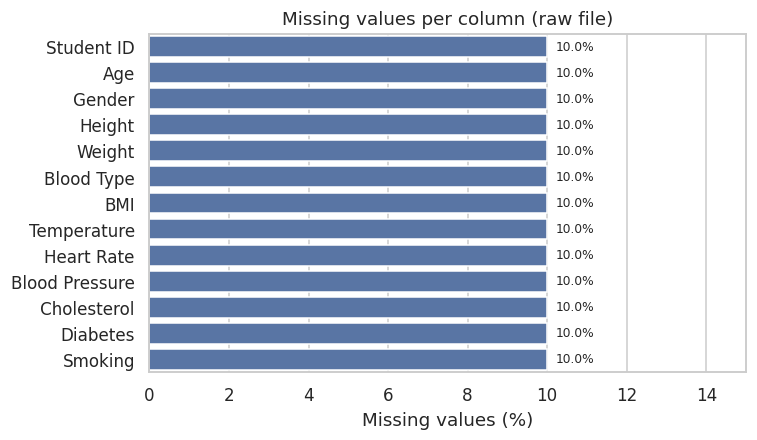

Total missing cells: 260000 (10.00% of the table)


In [ ]:
miss = (100 * raw.isna().mean()).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=miss.values, y=miss.index, color="#4C72B0")
plt.xlabel("Missing values (%)"); plt.ylabel("")
plt.title("Missing values per column (raw file)")
plt.xlim(0, 15)
for i, v in enumerate(miss.values):
    plt.text(v + 0.2, i, "%.1f%%" % v, va="center", fontsize=8)
save("fig_missing"); plt.show()

print("Total missing cells:", int(raw.isna().sum().sum()),
      "(%.2f%% of the table)" % (100 * raw.isna().mean().mean()))

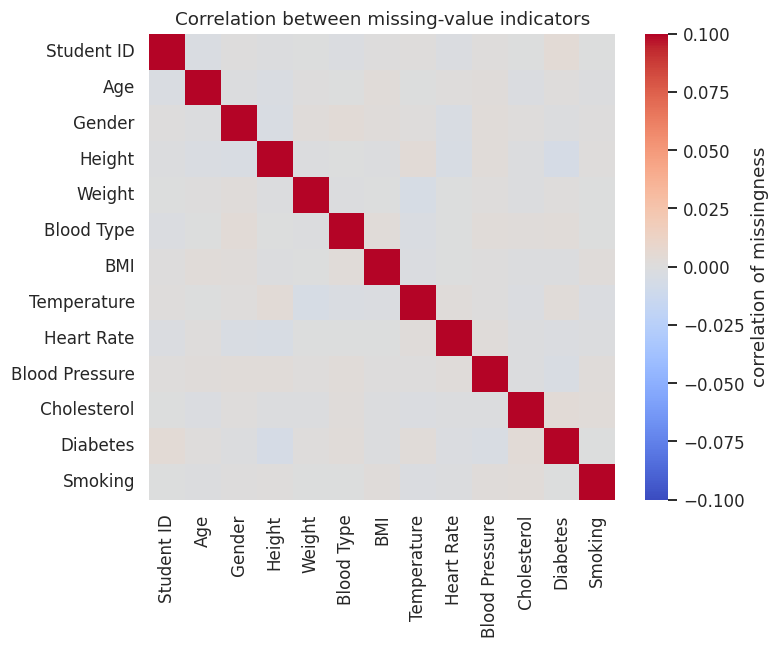

In [ ]:
# Is the missingness correlated between columns?  (an MCAR check)
plt.figure(figsize=(7, 5.5))
sns.heatmap(raw.isna().corr(), cmap="coolwarm", center=0, vmin=-.1, vmax=.1,
            square=True, cbar_kws={"label": "correlation of missingness"})
plt.title("Correlation between missing-value indicators")
save("fig_missing_corr"); plt.show()

Every column is missing exactly 10 % of its values, and the missingness indicators
are mutually uncorrelated. The data are therefore **Missing Completely At Random
(MCAR)** — the fact that a cell is blank tells us nothing about the student. This matters
because it means simple statistic-based imputation is safe here: it cannot introduce the
systematic bias that imputation would introduce under an MNAR mechanism.

### 3.2 Distribution of the target feature

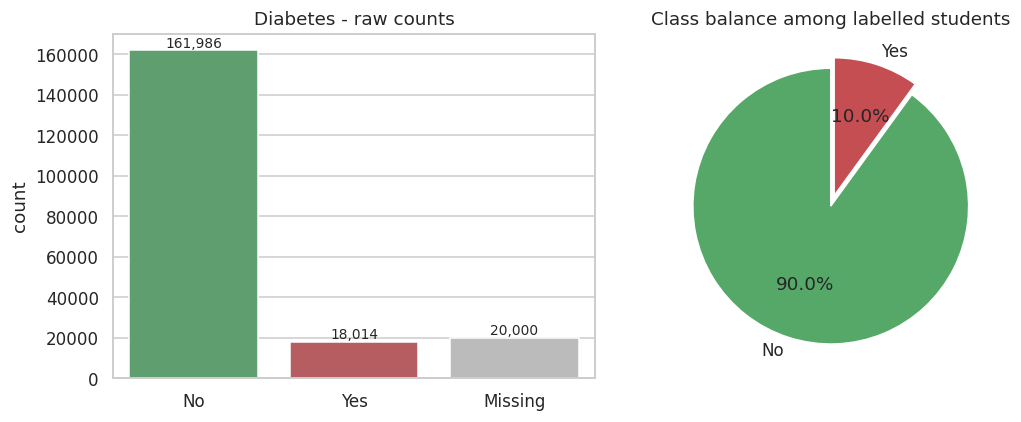

Diabetes
No     161986
Yes     18014

Positive-class (Yes) rate: 0.1001
Imbalance ratio          : 8.99 : 1


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=raw["Diabetes"].fillna("Missing"),
              order=["No", "Yes", "Missing"], ax=ax[0],
              palette=["#55A868", "#C44E52", "#BBBBBB"])
ax[0].set_title("Diabetes - raw counts"); ax[0].set_xlabel("")
for p in ax[0].patches:
    ax[0].annotate("{:,}".format(int(p.get_height())),
                   (p.get_x() + p.get_width() / 2, p.get_height()),
                   ha="center", va="bottom", fontsize=9)

known = raw["Diabetes"].dropna()
ax[1].pie(known.value_counts(), labels=known.value_counts().index, autopct="%1.1f%%",
          colors=["#55A868", "#C44E52"], startangle=90, explode=(0, .08))
ax[1].set_title("Class balance among labelled students")
plt.tight_layout(); save("fig_target_balance"); plt.show()

print(known.value_counts().to_string())
print("\nPositive-class (Yes) rate: %.4f" % (known == "Yes").mean())
print("Imbalance ratio          : %.2f : 1"
      % ((known == "No").sum() / (known == "Yes").sum()))

**Observation 1 — the dataset is heavily imbalanced.** Only **10.0 %** of labelled
students are diabetic, an imbalance ratio of about **9 : 1**. This immediately establishes
the *majority-class baseline*: a classifier that always answers `No` achieves **90 %
accuracy** with **0 % recall**. Every model we build must be judged against that baseline,
not against zero.

### 3.3 Distribution of the quantitative features

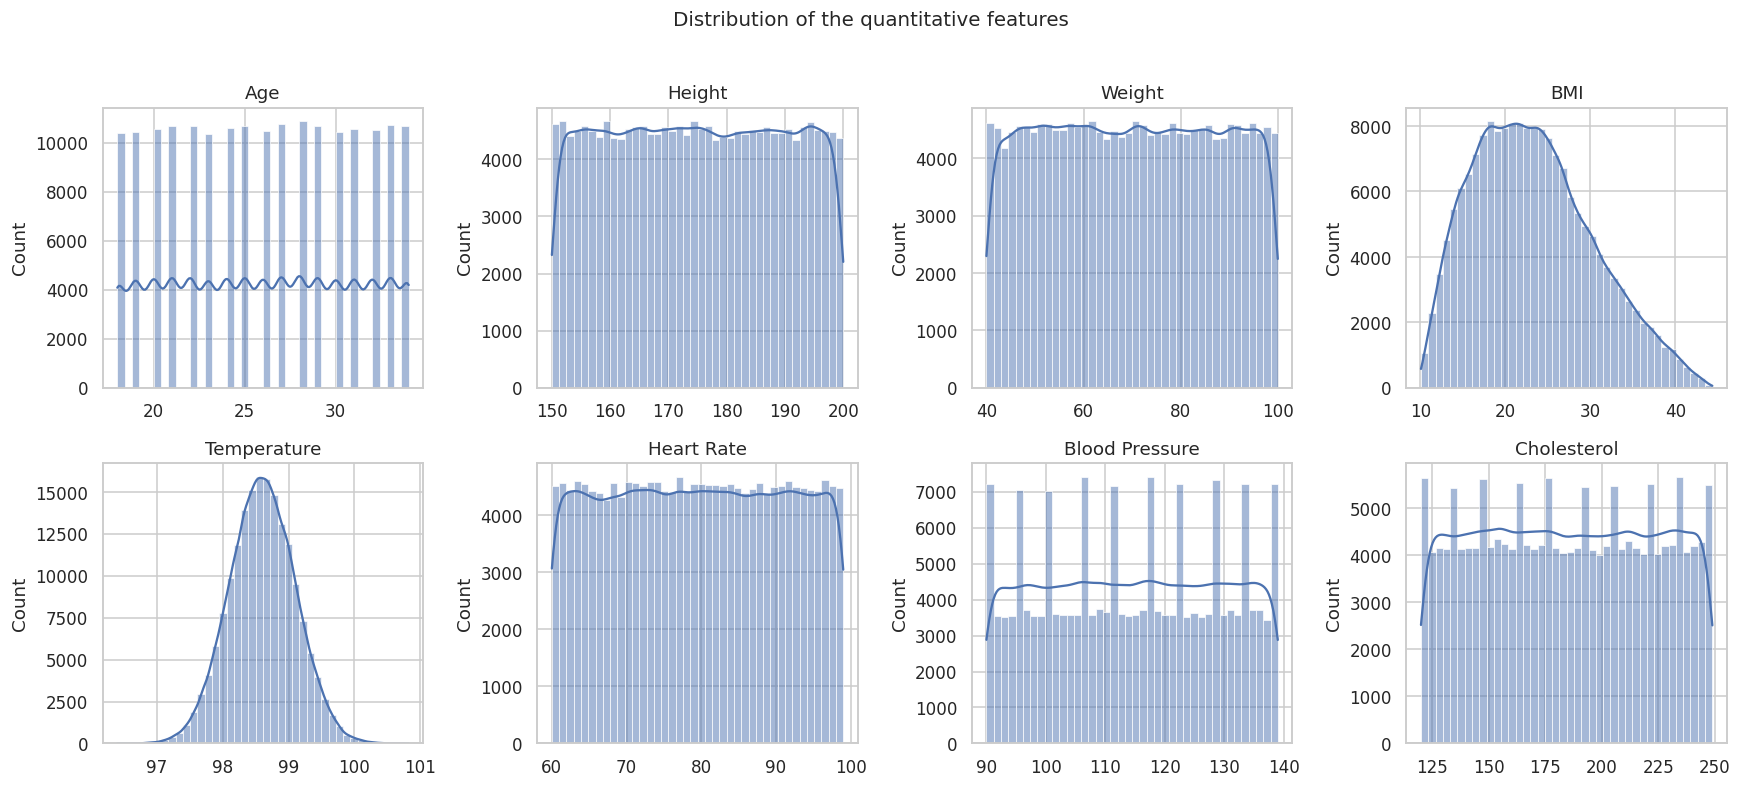

In [ ]:
numcols = ["Age", "Height", "Weight", "BMI", "Temperature",
           "Heart Rate", "Blood Pressure", "Cholesterol"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), numcols):
    sns.histplot(raw[c].dropna(), bins=40, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(c); ax.set_xlabel("")
plt.suptitle("Distribution of the quantitative features", y=1.02, fontsize=13)
plt.tight_layout(); save("fig_distributions"); plt.show()

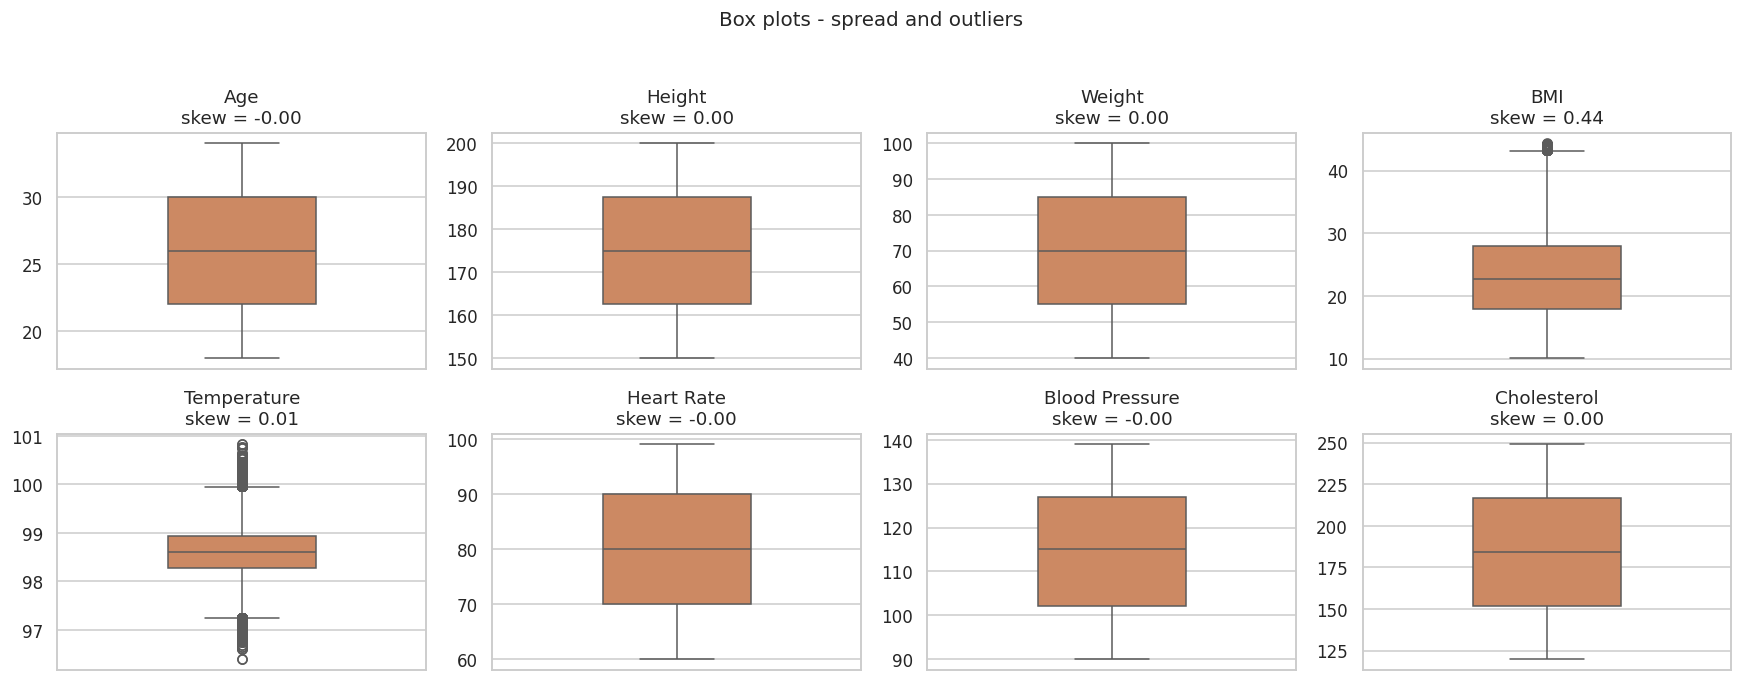

Age              -0.003
Height            0.002
Weight            0.005
BMI               0.438
Temperature       0.010
Heart Rate       -0.001
Blood Pressure   -0.005
Cholesterol       0.004


In [ ]:
# Skewness and outlier check
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, c in zip(axes.ravel(), numcols):
    sns.boxplot(y=raw[c].dropna(), ax=ax, color="#DD8452", width=.4)
    ax.set_title("%s\nskew = %.2f" % (c, raw[c].skew())); ax.set_ylabel("")
plt.suptitle("Box plots - spread and outliers", y=1.03, fontsize=13)
plt.tight_layout(); save("fig_boxplots"); plt.show()

print(raw[numcols].skew().round(3).to_string())

#### Variance of each numerical feature

In [ ]:
numerical_data = raw[numcols]
numerical_data.var().round(3)

,0
Age,23.917
Height,208.732
Weight,300.072
BMI,49.471
Temperature,0.251
Heart Rate,133.189
Blood Pressure,207.457
Cholesterol,1410.729


In [ ]:
# Variance side by side with skew, so the two are read together
pd.DataFrame({"variance": raw[numcols].var(),
              "std dev" : raw[numcols].std(),
              "skew"    : raw[numcols].skew()}).round(3)

,variance,std dev,skew
Age,23.917,4.891,-0.003
Height,208.732,14.448,0.002
Weight,300.072,17.323,0.005
BMI,49.471,7.034,0.438
Temperature,0.251,0.501,0.010
Heart Rate,133.189,11.541,-0.001
Blood Pressure,207.457,14.403,-0.005
Cholesterol,1410.729,37.560,0.004


`Cholesterol` has a variance of roughly 1,410 while `Temperature` has about 0.25 —
a spread of nearly four orders of magnitude. Left unscaled, Cholesterol would completely
dominate the Euclidean distances used by KNN and k-means. This is the concrete
justification for the standardisation step in Section 4.6.

**Observation 2 — the features are almost all uniform, not physiological.** Age,
Height, Weight, Heart Rate, Blood Pressure and Cholesterol are *flat* between hard minimum
and maximum bounds (Age is uniform on 18–34, Weight uniform on 40–100 kg), with skewness
near zero and no outliers whatsoever. Real anthropometric measurements are approximately
Gaussian with a long right tail. Only `Temperature` is bell-shaped, and only `BMI` is
right-skewed — and Section 3.4 shows that BMI's shape is inherited arithmetically from
Height and Weight. This is strong evidence that the features were drawn from independent
uniform distributions by a data generator.

### 3.4 Correlation structure between the features

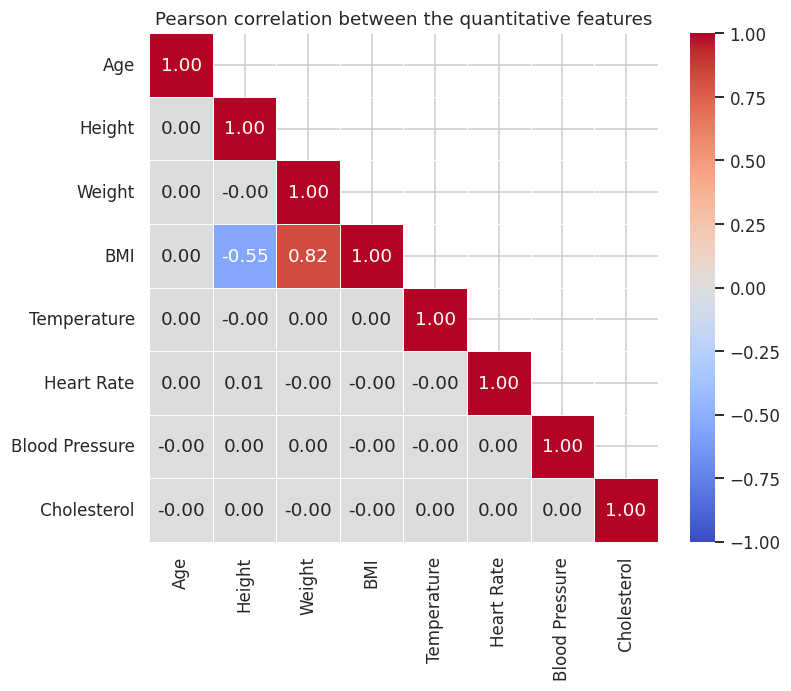

In [ ]:
corr = raw[numcols].corr()

plt.figure(figsize=(7.5, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Pearson correlation between the quantitative features")
save("fig_corr"); plt.show()

corr(BMI, Weight/Height^2)   : 1.0
mean |BMI - Weight/Height^2| : 0.0
max  |BMI - Weight/Height^2| : 0.0


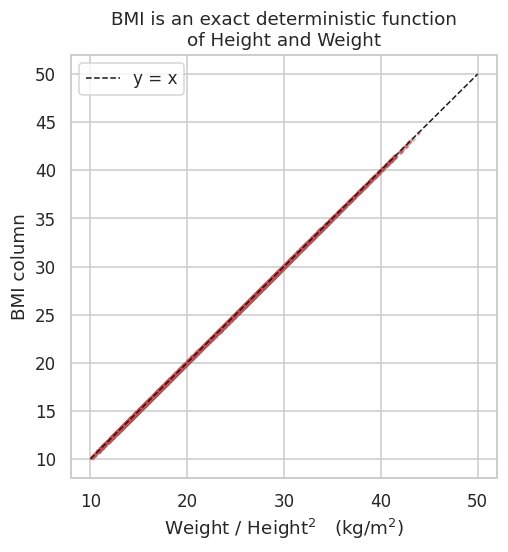

In [ ]:
# The one real relationship in the data: is BMI literally weight / height^2 ?
chk = raw[["Height", "Weight", "BMI"]].dropna()
bmi_formula = chk["Weight"] / (chk["Height"] / 100) ** 2

print("corr(BMI, Weight/Height^2)   :", round(np.corrcoef(chk["BMI"], bmi_formula)[0, 1], 6))
print("mean |BMI - Weight/Height^2| :", round((chk["BMI"] - bmi_formula).abs().mean(), 10))
print("max  |BMI - Weight/Height^2| :", round((chk["BMI"] - bmi_formula).abs().max(), 10))

plt.figure(figsize=(5, 5))
s = chk.sample(4000, random_state=RANDOM_STATE)
plt.scatter(s["Weight"] / (s["Height"] / 100) ** 2, s["BMI"],
            s=4, alpha=.3, color="#C44E52")
plt.plot([10, 50], [10, 50], "k--", lw=1, label="y = x")
plt.xlabel(r"Weight / Height$^2$   (kg/m$^2$)"); plt.ylabel("BMI column")
plt.title("BMI is an exact deterministic function\nof Height and Weight")
plt.legend(); save("fig_bmi_identity"); plt.show()

**Observation 3 — two findings from the correlation structure.**

1. **All genuinely independent features are mutually uncorrelated** (|r| < 0.01). Height
   and Weight are uncorrelated, which is physiologically impossible in a real population —
   taller people weigh more. Again, the generator drew them independently.
2. **`BMI` is perfectly redundant.** The identity
   $\mathrm{BMI} = \mathrm{Weight}/(\mathrm{Height}/100)^{2}$ holds *exactly*
   (correlation 1.000000, maximum absolute error 0.0). `BMI` therefore contributes zero
   new information beyond `Height` and `Weight`, while introducing severe
   multicollinearity that destabilises logistic-regression coefficients and double-counts
   body size in every distance-based model. This is the one real structural relationship
   in the dataset, and Section 4.5 acts on it.

### 3.5 Relationship between each feature and the target

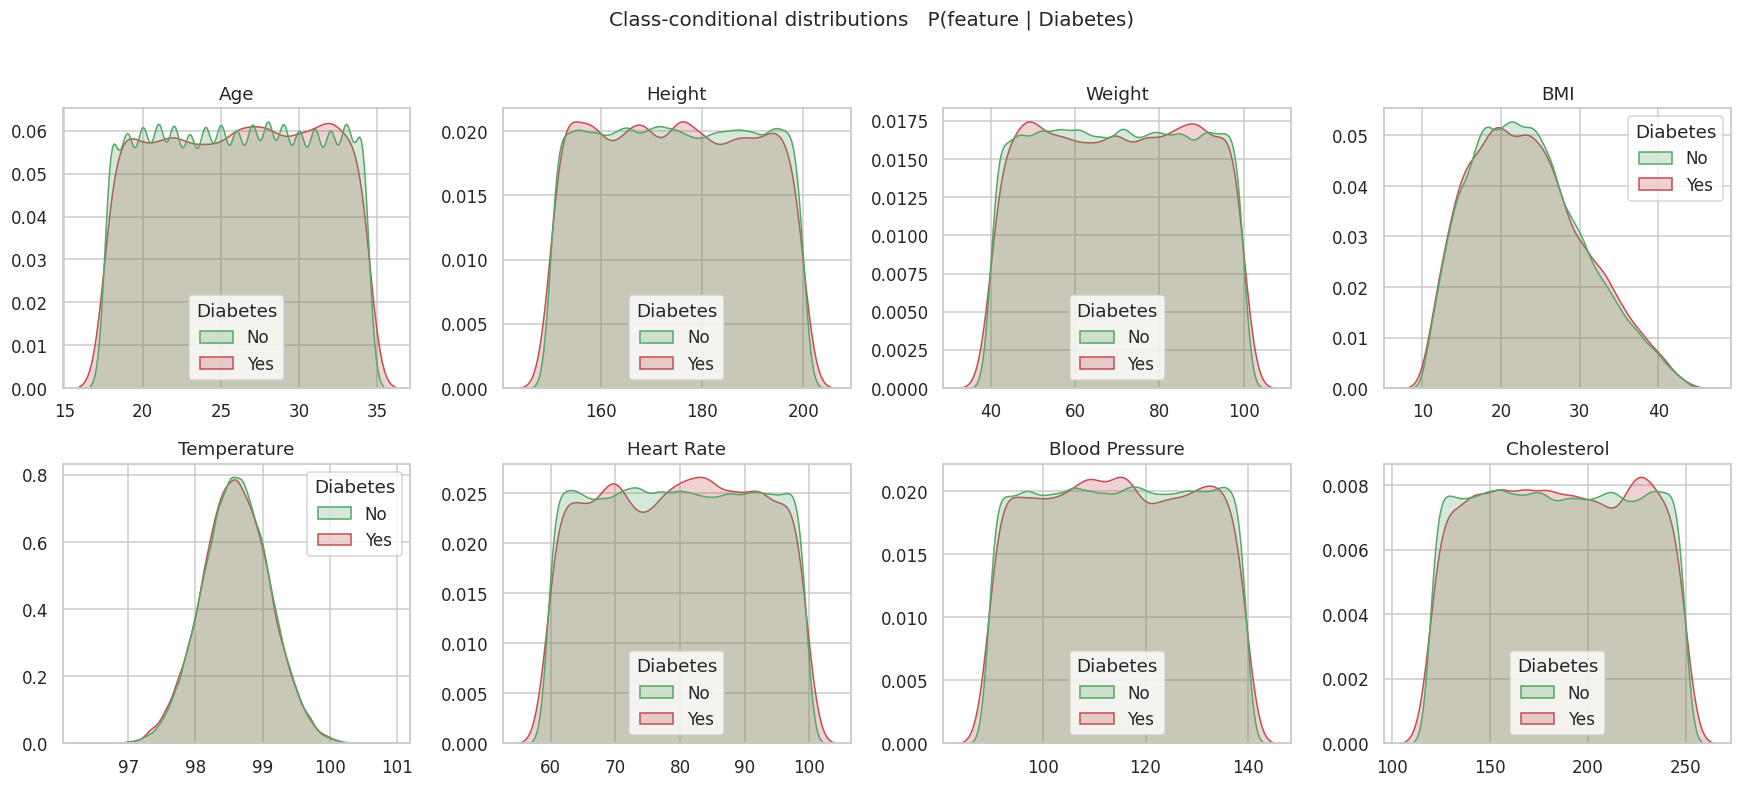

In [ ]:
lab = raw.dropna(subset=["Diabetes"])

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), numcols):
    sns.kdeplot(data=lab, x=c, hue="Diabetes", common_norm=False,
                fill=True, alpha=.25, ax=ax,
                palette={"No": "#55A868", "Yes": "#C44E52"})
    ax.set_title(c); ax.set_xlabel(""); ax.set_ylabel("")
plt.suptitle("Class-conditional distributions   P(feature | Diabetes)",
             y=1.02, fontsize=13)
plt.tight_layout(); save("fig_kde_by_class"); plt.show()

In [ ]:
# Group means per class, with the relative gap between them
gm = lab.groupby("Diabetes")[numcols].mean().T
gm.columns = ["mean | No", "mean | Yes"]
gm["difference"]   = gm["mean | Yes"] - gm["mean | No"]
gm["difference %"] = (100 * gm["difference"] / gm["mean | No"]).round(3)
gm.round(3)

,mean | No,mean | Yes,difference,difference %
Age,26.021,26.081,0.060,0.229
Height,174.968,174.648,-0.320,-0.183
Weight,69.979,70.134,0.155,0.222
BMI,23.342,23.397,0.055,0.236
Temperature,98.602,98.591,-0.011,-0.011
Heart Rate,79.490,79.584,0.094,0.119
Blood Pressure,114.563,114.496,-0.067,-0.058
Cholesterol,184.441,184.804,0.363,0.197


In [ ]:
# Cohen's d - a scale-free effect size for every quantitative feature
rows = []
for c in numcols:
    a = lab.loc[lab.Diabetes == "Yes", c].dropna()
    b = lab.loc[lab.Diabetes == "No",  c].dropna()
    sp = np.sqrt(((len(a) - 1) * a.var() + (len(b) - 1) * b.var())
                 / (len(a) + len(b) - 2))
    rows.append({"feature": c, "cohens_d": (a.mean() - b.mean()) / sp})

eff = (pd.DataFrame(rows).set_index("feature")
         .sort_values("cohens_d", key=abs, ascending=False))
print(eff.round(4).to_string())
print("\nConvention: |d| < 0.2 negligible, 0.2 small, 0.5 medium, 0.8 large.")

                cohens_d
feature                 
Height           -0.0222
Temperature      -0.0216
Age               0.0122
Cholesterol       0.0097
Weight            0.0090
Heart Rate        0.0082
BMI               0.0078
Blood Pressure   -0.0046

Convention: |d| < 0.2 negligible, 0.2 small, 0.5 medium, 0.8 large.


#### Barplot of unique value counts in every categorical feature

Following the EDA lab, we first look at each categorical feature on its own, before
relating it to the target.

Number of unique values in each categorical feature:
Gender        2
Blood Type    4
Smoking       2 



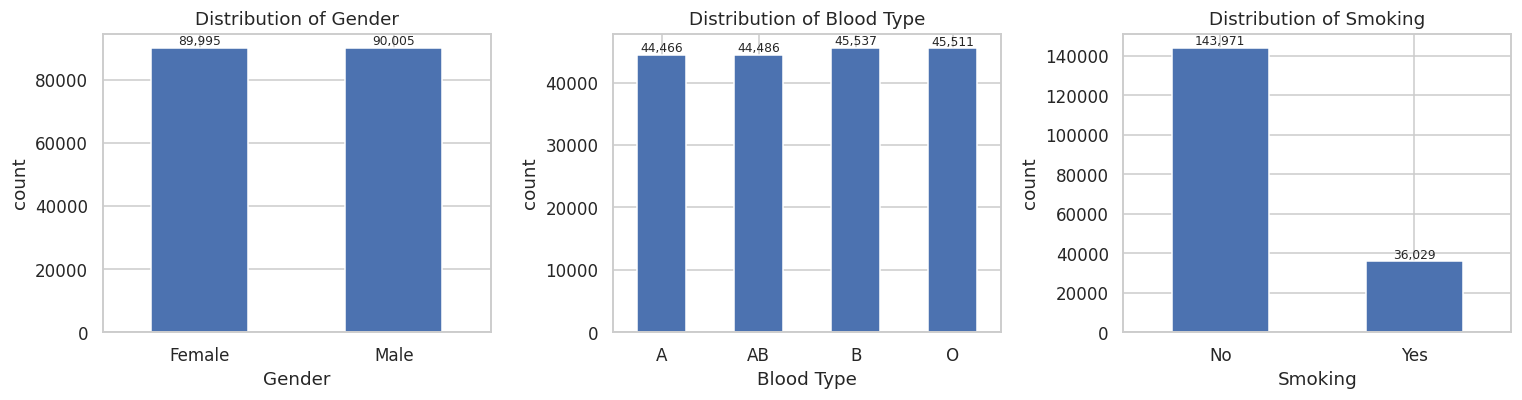

In [ ]:
categorical_features = ["Gender", "Blood Type", "Smoking"]
categorical_data = raw[categorical_features]

print("Number of unique values in each categorical feature:")
print(categorical_data.nunique().to_string(), "\n")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col in zip(axes, categorical_features):
    categorical_data[col].value_counts().sort_index().plot(
        kind="bar", rot=0, ax=ax, color="#4C72B0")
    ax.set_title("Distribution of %s" % col)
    ax.set_xlabel(col); ax.set_ylabel("count")
    for p in ax.patches:
        ax.annotate("{:,}".format(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8)
plt.tight_layout(); save("fig_categorical_counts"); plt.show()

Every categorical feature is almost perfectly balanced across its levels: Gender
splits 50/50, the four blood types each take roughly a quarter, and Smoking is a clean
80/20. Real populations are rarely this even. It is one more sign of a uniform random
generator, and it also means no category is too rare to estimate a diabetes rate for --
which makes the flat rates in the next subsection trustworthy rather than noisy.

### 3.6 Categorical features versus the target

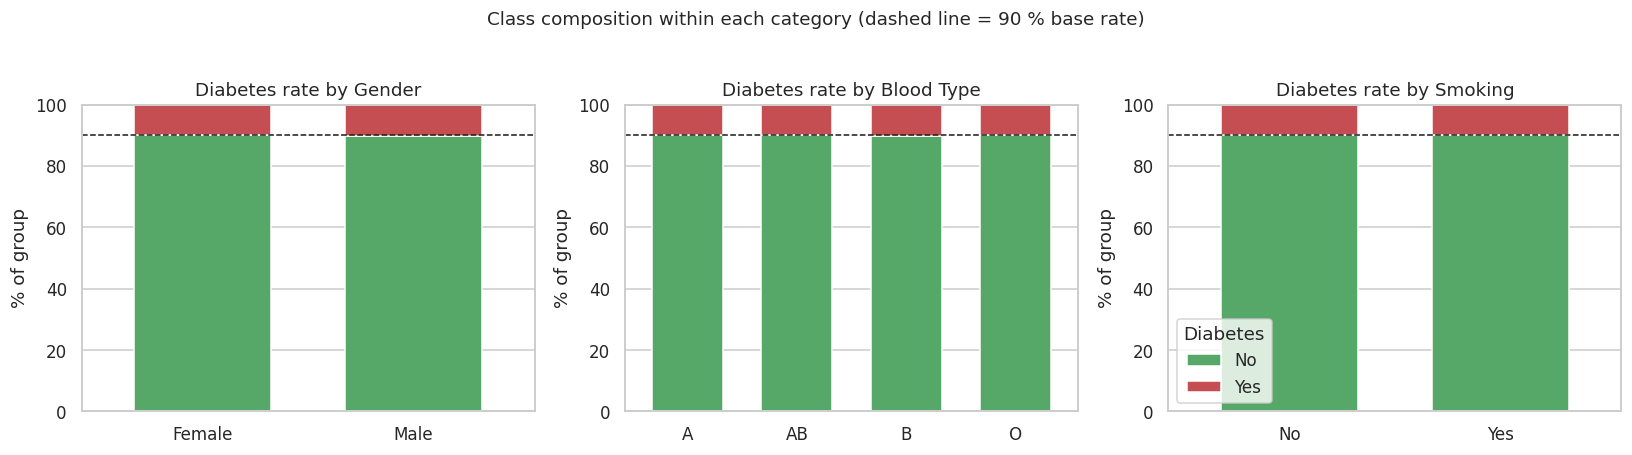

--- P(Diabetes = Yes | Gender) ---
Gender
Female    0.0989
Male      0.1010 

--- P(Diabetes = Yes | Blood Type) ---
Blood Type
A     0.1004
AB    0.0994
B     0.1009
O     0.0993 

--- P(Diabetes = Yes | Smoking) ---
Smoking
No     0.0996
Yes    0.0999 



In [ ]:
catcols = ["Gender", "Blood Type", "Smoking"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, catcols):
    ct = pd.crosstab(lab[c], lab["Diabetes"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#55A868", "#C44E52"],
            width=.65, legend=(ax is axes[-1]))
    ax.axhline(90, ls="--", c="k", lw=1)
    ax.set_title("Diabetes rate by %s" % c)
    ax.set_xlabel(""); ax.set_ylabel("% of group")
    ax.tick_params(axis="x", rotation=0); ax.set_ylim(0, 100)
plt.suptitle("Class composition within each category (dashed line = 90 % base rate)",
             y=1.03, fontsize=12)
plt.tight_layout(); save("fig_categorical"); plt.show()

for c in catcols:
    print("--- P(Diabetes = Yes | %s) ---" % c)
    print(pd.crosstab(lab[c], lab["Diabetes"],
                      normalize="index")["Yes"].round(4).to_string(), "\n")

### 3.7 The decisive plot: risk profile across feature deciles

A linear correlation of zero does not rule out a *non-linear* relationship — diabetes risk
could, for instance, be elevated only at the extremes of BMI. To test this we split each
quantitative feature into ten equal-sized bins (deciles) and plot the observed diabetes
rate inside each bin. If a feature carried any signal at all, linear or not, the curve
would bend away from the 10 % base rate.

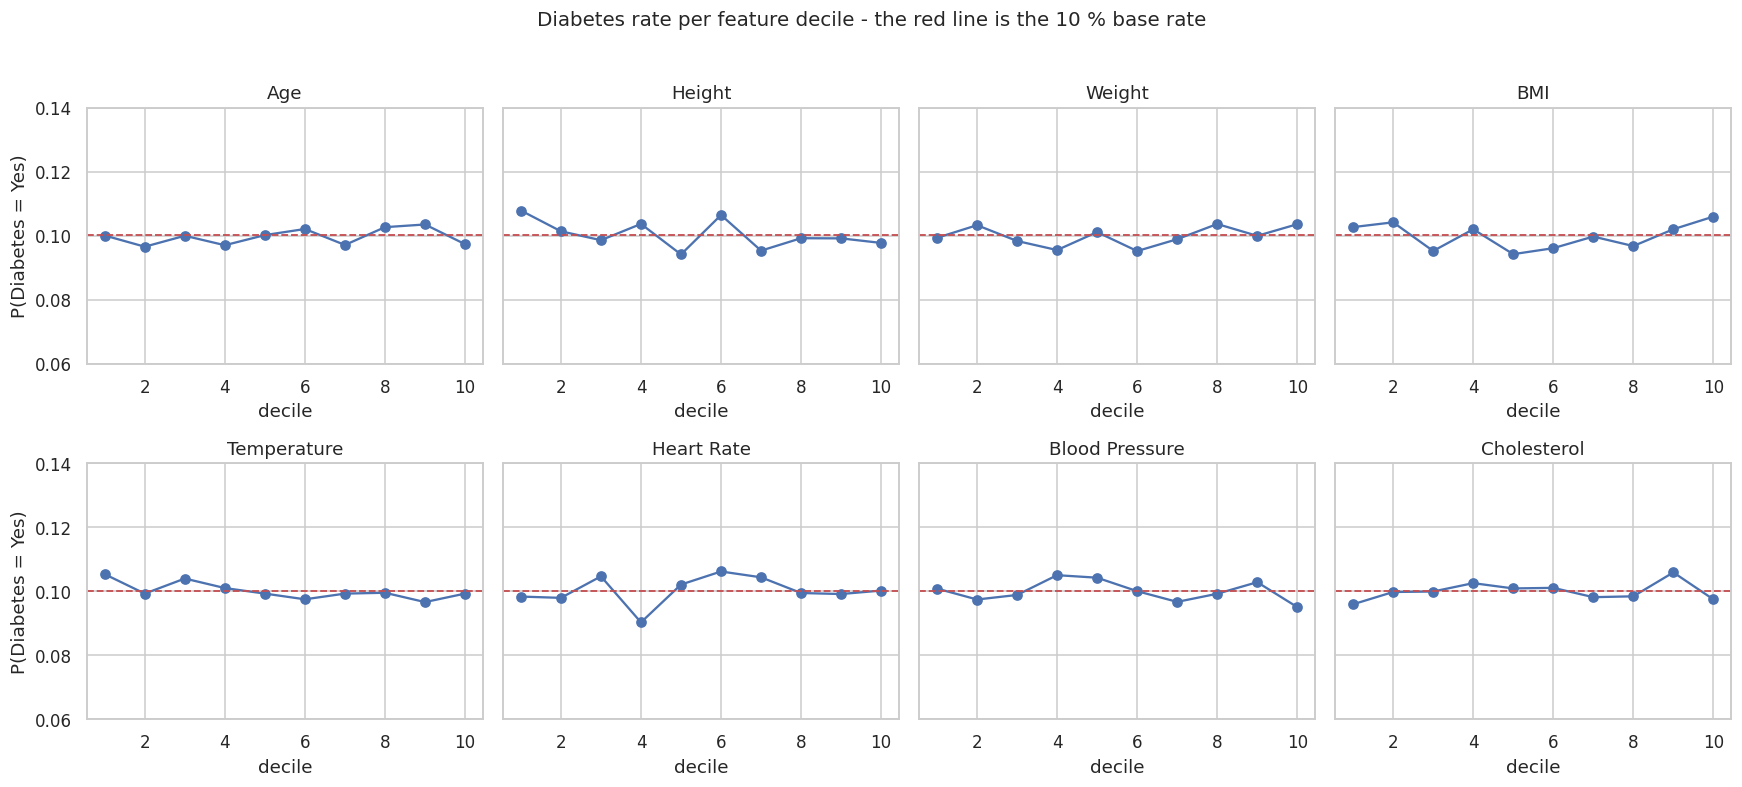

Range of the diabetes rate across the ten deciles:
Heart Rate        0.0159
Height            0.0137
BMI               0.0117
Blood Pressure    0.0100
Cholesterol       0.0099
Temperature       0.0087
Weight            0.0084
Age               0.0069


In [ ]:
y_lab = (lab["Diabetes"] == "Yes").astype(int)
base  = y_lab.mean()

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
prof = {}
for ax, c in zip(axes.ravel(), numcols):
    m    = lab[c].notna()
    bins = pd.qcut(lab.loc[m, c], 10, labels=False, duplicates="drop")
    rate = y_lab[m].groupby(bins).mean()
    prof[c] = rate.values
    ax.plot(rate.index + 1, rate.values, "o-", color="#4C72B0")
    ax.axhline(base, ls="--", c="#C44E52", lw=1.2)
    ax.set_title(c); ax.set_xlabel("decile"); ax.set_ylim(0.06, 0.14)
axes[0, 0].set_ylabel("P(Diabetes = Yes)")
axes[1, 0].set_ylabel("P(Diabetes = Yes)")
plt.suptitle("Diabetes rate per feature decile - the red line is the 10 % base rate",
             y=1.02, fontsize=13)
plt.tight_layout(); save("fig_decile_profile"); plt.show()

spread = pd.Series({c: v.max() - v.min() for c, v in prof.items()}
                   ).sort_values(ascending=False)
print("Range of the diabetes rate across the ten deciles:")
print(spread.round(4).to_string())

**Observation 4 — no feature carries any signal about the target.** Every decile
curve is flat at the 10 % base rate; the entire range from the lowest to the highest
decile is at most a couple of percentage points, which is within the binomial sampling
noise of roughly 18,000 observations per bin (the widest spread of any feature is
1.6 percentage points, for Heart Rate). The Cohen's *d* values in Section 3.5 are all at
most **0.022** in absolute value — the threshold for a merely "negligible" effect is 0.2,
so ours are an order of magnitude smaller — and the categorical breakdowns in Section 3.6
are flat at 10 % for every sex, every blood type and both smoking statuses.

The exploratory analysis therefore already tells us what to expect: **the features and the
target in this dataset are statistically independent.** The modelling sections that follow
confirm it quantitatively.

---
## 4. Dataset Pre-processing

Following the guideline, each subsection below states **one problem** and then the
technique applied to solve it.

### 4.1 Problem 1 — hidden record duplication (data leakage)

`raw.duplicated()` reports 7,644 identical rows, which a naive pipeline would simply drop.
But the real defect is far more serious and completely invisible to `drop_duplicates()`.

Notice that `Student ID` runs from 1 to 100,000 while the file has 200,000 rows. The
hypothesis is that the file is **two masked copies of the same 100,000-record table**
stacked vertically: row *i* and row *i* + 100,000 describe the **same student**, but a
*different* random 10 % of their cells has been blanked out in each copy. Because the two
copies have different blanks they are not byte-identical, so `drop_duplicates()` misses
them entirely.

If that is true, a random train/test split puts one copy of a student into the training
set and the other copy into the test set — textbook **data leakage**, which silently
inflates every metric we report. Let us test the hypothesis before trusting it.

In [ ]:
n_half = len(raw) // 2
A = raw.iloc[:n_half].reset_index(drop=True)
B = raw.iloc[n_half:].reset_index(drop=True)

overlap = conflict = 0
for c in raw.columns:
    both      = A[c].notna() & B[c].notna()
    overlap  += int(both.sum())
    conflict += int((A.loc[both, c] != B.loc[both, c]).sum())

print("Student ID range             : %.0f - %.0f"
      % (raw["Student ID"].min(), raw["Student ID"].max()))
print("Rows in the file             : {:,}".format(len(raw)))
print("Cells present in BOTH halves : {:,}".format(overlap))
print("Cells that DISAGREE          : {:,}".format(conflict))
print()
if conflict == 0:
    print("CONFIRMED: zero conflicts - the two halves are masked copies of one table.")
else:
    print("Hypothesis rejected - the halves are independent records.")

Student ID range             : 1 - 100000
Rows in the file             : 200,000
Cells present in BOTH halves : 1,052,964
Cells that DISAGREE          : 0

CONFIRMED: zero conflicts - the two halves are masked copies of one table.


In [ ]:
# Example: the very first student appears twice, with different cells blanked
pd.concat([raw.iloc[[0]], raw.iloc[[n_half]]])

,Student ID,Age,Gender,Height,Weight,Blood Type,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Diabetes,Smoking
0,1.0,18.0,Female,161.777924,72.354947,O,27.645835,NaN,95.0,109.0,203.0,No,NaN
100000,NaN,18.0,Female,161.777924,72.354947,O,27.645835,98.614398,95.0,NaN,203.0,No,Yes


Over **1.05 million** overlapping cells there is **not a single disagreement**. The
hypothesis is confirmed.

**Solution.** We *merge* the two halves with `combine_first` rather than dropping one of
them. This does two things at once:

* it collapses the 200,000 rows back to the **100,000 genuine records**, removing the
  leakage completely; and
* because a cell is only still blank if it was masked in *both* copies, it **recovers most
  of the missing data** — the missing rate falls from 10 % to roughly
  0.1 x 0.1 = **1 %**.

Merging is strictly better than dropping the duplicate half, which would have thrown away
all of those recoverable values.

In [ ]:
merged = A.combine_first(B)
merged = merged.drop(columns=["Student ID"])       # identifier: no predictive value

before = 100 * raw.isna().mean().mean()
after  = 100 * merged.isna().mean().mean()
print("Rows      : {:,}  ->  {:,}".format(len(raw), len(merged)))
print("Missing pct: %.2f%%  ->  %.2f%%" % (before, after))

# Any exact duplicates remaining now are genuinely repeated records
print("\nExact duplicate rows remaining:", int(merged.duplicated().sum()))
merged = merged.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", merged.shape)

Rows      : 200,000  ->  100,000
Missing pct: 10.00%  ->  1.00%

Exact duplicate rows remaining: 0
Shape after de-duplication: (100000, 12)


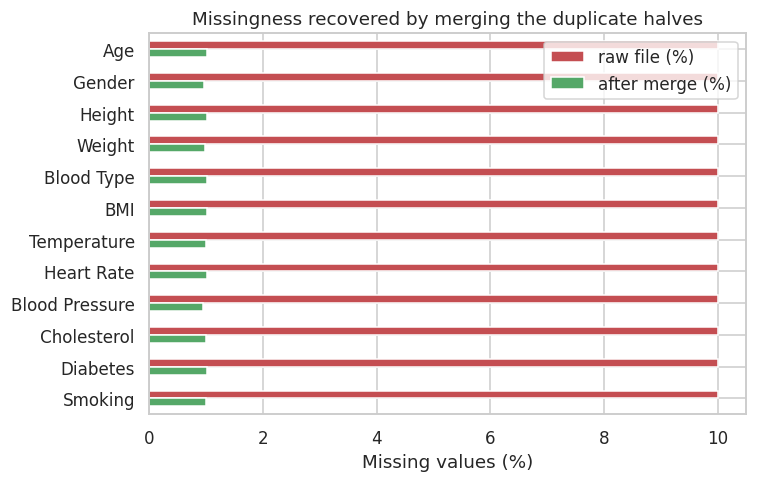

,raw file (%),after merge (%)
Age,10.0,1.02
Gender,10.0,0.96
Height,10.0,1.01
Weight,10.0,0.97
Blood Type,10.0,1.01
BMI,10.0,1.02
Temperature,10.0,0.99
Heart Rate,10.0,1.01
Blood Pressure,10.0,0.94
Cholesterol,10.0,1.00


In [ ]:
cmp = pd.DataFrame({
    "raw file (%)"   : 100 * raw.drop(columns=["Student ID"]).isna().mean(),
    "after merge (%)": 100 * merged.isna().mean(),
}).round(2)

cmp.plot(kind="barh", figsize=(7, 4.5), color=["#C44E52", "#55A868"])
plt.xlabel("Missing values (%)")
plt.title("Missingness recovered by merging the duplicate halves")
plt.gca().invert_yaxis(); save("fig_missing_recovered"); plt.show()
cmp

### 4.2 Problem 2 — rows with a missing label



In [ ]:
TARGET = "Diabetes"
print("Rows with a missing label:", int(merged[TARGET].isna().sum()))

data = merged.dropna(subset=[TARGET]).reset_index(drop=True)
print("Rows kept:", len(data))
print("\nThe class balance is preserved:")
print(data[TARGET].value_counts(normalize=True).round(4).to_string())

Rows with a missing label: 1007
Rows kept: 98993

The class balance is preserved:
Diabetes
No     0.9
Yes    0.1


### 4.3 Problem 3 — remaining null values in the features

Roughly 1 % of the feature cells are still blank. Both `scikit-learn` estimators and Keras
raise an error on `NaN`, so these must be filled. Deleting the affected rows would discard
about 10 % of the records for the sake of 1 % of the cells.

**Solution — statistic-based imputation**, chosen per feature type:

* **Quantitative features → median.** The median is robust to outliers and, unlike the
  mean, is not dragged by skew (`BMI` is right-skewed, Section 3.3).
* **Categorical features → mode.** The most frequent category is the maximum-likelihood
  fill for a nominal variable.

This is safe precisely because the data are MCAR: the imputed values cannot bias the
feature–target relationship, because no mechanism links blankness to the student.

In [ ]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in data.columns if c not in num_cols and c != TARGET]
print("Quantitative:", num_cols)
print("Categorical :", cat_cols)

for c in num_cols:
    data[c] = data[c].fillna(data[c].median())
for c in cat_cols:
    data[c] = data[c].fillna(data[c].mode()[0])

print("\nRemaining nulls:", int(data.isna().sum().sum()))

Quantitative: ['Age', 'Height', 'Weight', 'BMI', 'Temperature', 'Heart Rate', 'Blood Pressure', 'Cholesterol']
Categorical : ['Gender', 'Blood Type', 'Smoking']

Remaining nulls: 0


### 4.4 Problem 4 — categorical values cannot be fed to a model

`Gender`, `Blood Type` and `Smoking` are strings, and every model used here needs numeric
input.

**Solution.**

* **Target `Diabetes` → binary label encoding**, `Yes` -> 1 (the positive, minority class)
  and `No` -> 0, so that precision and recall refer to the clinically interesting class.
* **Binary predictors (`Gender`, `Smoking`) → one-hot with `drop_first=True`**, which
  yields a single 0/1 column and avoids the dummy-variable trap.
* **`Blood Type` → one-hot encoding.** Blood type is *nominal*: A, AB, B and O have no
  ordering. Assigning it the integer codes 0–3 would falsely tell the model that
  `O - A = 3` and that AB lies between A and B — an artificial ordering that a
  distance-based model such as KNN would take literally. One-hot encoding avoids inventing
  it.

In [ ]:
y = (data[TARGET] == "Yes").astype(int)
X = pd.get_dummies(data.drop(columns=[TARGET]),
                   columns=cat_cols, drop_first=True).astype(float)

print("Encoded feature matrix:", X.shape)
print("Label encoding: No -> 0, Yes -> 1;  positive rate =", round(y.mean(), 4))
X.head()

Encoded feature matrix: (98993, 13)
Label encoding: No -> 0, Yes -> 1;  positive rate = 0.1


,Age,Height,Weight,BMI,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Male,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_Yes
0,18.0,161.777924,72.354947,27.645835,98.614398,95.0,109.0,203.0,0.0,0.0,0.0,1.0,1.0
1,34.0,152.069157,47.630941,20.597139,98.714977,93.0,104.0,163.0,1.0,0.0,1.0,0.0,0.0
2,32.0,182.537664,55.741083,16.729017,98.260293,76.0,130.0,216.0,0.0,0.0,0.0,0.0,0.0
3,30.0,182.112867,63.332207,19.096042,98.839605,99.0,112.0,141.0,1.0,0.0,1.0,0.0,1.0
4,23.0,179.339293,46.234173,14.375143,98.480008,95.0,139.0,231.0,0.0,0.0,0.0,1.0,0.0


### 4.5 Problem 5 — a perfectly redundant feature (multicollinearity)

Section 3.4 established that `BMI` is an *exact* function of `Height` and `Weight`. A
feature that is a deterministic function of two others adds no information, but it does add
multicollinearity: it inflates the variance of logistic-regression coefficients and makes
them uninterpretable, and it distorts Euclidean distances in KNN and k-means by counting
body size twice.

**Solution — feature selection.** We quantify the usefulness of every feature with
**mutual information**, which unlike Pearson correlation also detects *non-linear*
dependence, and we inspect the variance-inflation factor of the body-size block.

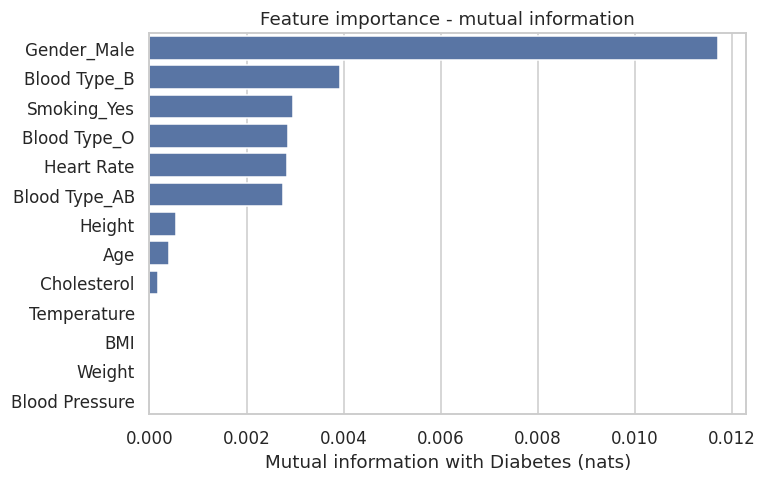

Gender_Male       0.011701
Blood Type_B      0.003915
Smoking_Yes       0.002952
Blood Type_O      0.002846
Heart Rate        0.002838
Blood Type_AB     0.002750
Height            0.000557
Age               0.000403
Cholesterol       0.000171
Temperature       0.000000
BMI               0.000000
Weight            0.000000
Blood Pressure    0.000000

Largest MI in the whole feature set : 0.011701 nats
Entropy of the target H(y)          : 0.325076 nats
Best feature explains                : 3.60% of the label's uncertainty


In [ ]:
mi = pd.Series(mutual_info_classif(X, y, random_state=RANDOM_STATE),
               index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=mi.values, y=mi.index, color="#4C72B0")
plt.xlabel("Mutual information with Diabetes (nats)"); plt.ylabel("")
plt.title("Feature importance - mutual information")
save("fig_mutual_info"); plt.show()

p = y.mean()
H = -(p * np.log(p) + (1 - p) * np.log(1 - p))
print(mi.round(6).to_string())
print("\nLargest MI in the whole feature set : %.6f nats" % mi.max())
print("Entropy of the target H(y)          : %.6f nats" % H)
print("Best feature explains                : %.2f%% of the label's uncertainty"
      % (100 * mi.max() / H))

In [ ]:
# Variance-inflation factor for the body-size block
def vif(frame, col):
    others = frame.drop(columns=[col])
    r2 = LinearRegression().fit(others, frame[col]).score(others, frame[col])
    return np.inf if r2 >= 1 - 1e-12 else 1 / (1 - r2)

body = X[["Height", "Weight", "BMI"]]
for c in body.columns:
    print("VIF(%-6s) = %.1f" % (c, vif(body, c)))
print("\n(A VIF above 10 is the usual red flag for multicollinearity.)")

VIF(Height) = 7.9
VIF(Weight) = 16.4
VIF(BMI   ) = 23.4

(A VIF above 10 is the usual red flag for multicollinearity.)


#### Dropping a column based on correlation

The pre-processing lab removes redundant features by finding columns whose correlation with
another column exceeds a threshold and dropping them. We apply that procedure here.

In [ ]:
# Correlation of every encoded feature with every other, ignoring the diagonal
corr_X  = X.corr().abs()
upper   = corr_X.where(np.triu(np.ones(corr_X.shape, dtype=bool), k=1))

THRESHOLD = 0.75
to_drop = [c for c in upper.columns if (upper[c] > THRESHOLD).any()]

print("Pairs above the %.2f threshold:" % THRESHOLD)
pairs = (upper.stack().sort_values(ascending=False))
print(pairs[pairs > THRESHOLD].round(4).to_string() or "  (none)")
print("\nColumn(s) selected for dropping:", to_drop)

Pairs above the 0.75 threshold:
Weight  BMI    0.813

Column(s) selected for dropping: ['BMI']


In [ ]:
# Apply the drop, exactly as the pre-processing lab does
X_reduced = X.drop(columns=to_drop)
print("Before:", X.shape, " ->  after:", X_reduced.shape)
X_reduced.head()

Before: (98993, 13)  ->  after: (98993, 12)


,Age,Height,Weight,Temperature,Heart Rate,Blood Pressure,Cholesterol,Gender_Male,Blood Type_AB,Blood Type_B,Blood Type_O,Smoking_Yes
0,18.0,161.777924,72.354947,98.614398,95.0,109.0,203.0,0.0,0.0,0.0,1.0,1.0
1,34.0,152.069157,47.630941,98.714977,93.0,104.0,163.0,1.0,0.0,1.0,0.0,0.0
2,32.0,182.537664,55.741083,98.260293,76.0,130.0,216.0,0.0,0.0,0.0,0.0,0.0
3,30.0,182.112867,63.332207,98.839605,99.0,112.0,141.0,1.0,0.0,1.0,0.0,1.0
4,23.0,179.339293,46.234173,98.480008,95.0,139.0,231.0,0.0,0.0,0.0,1.0,0.0


The threshold rule selects **`BMI`**, which is the correct answer: Section 3.4
proved BMI is an exact function of Height and Weight, and it correlates 0.82 with Weight.
The lab's procedure therefore finds the redundancy we identified by inspection.

**Does dropping it change anything?** Because the whole feature set is uninformative, it
should not. We verify rather than assume, by training a quick logistic regression on both
matrices.

In [ ]:
# Does removing the redundant column change predictive performance?
from sklearn.model_selection import cross_val_score

for label, mat in [("with BMI (13 features)", X), ("without BMI (12 features)", X_reduced)]:
    sc_tmp  = StandardScaler().fit_transform(mat)
    auc_cv  = cross_val_score(LogisticRegression(max_iter=1000), sc_tmp, y,
                              cv=3, scoring="roc_auc")
    print("%-26s AUC %.4f  (+/- %.4f)" % (label, auc_cv.mean(), auc_cv.std()))

with BMI (13 features)     AUC 0.5019  (+/- 0.0033)
without BMI (12 features)  AUC 0.5024  (+/- 0.0031)


Both matrices give an AUC of about 0.50. Dropping the redundant column removes the
multicollinearity --- which is worth doing for the *interpretability* of the logistic
regression coefficients --- but changes predictive performance not at all, because there was
no performance to lose. We therefore continue the main comparison with the **full** matrix
`X`, so that no model can be accused of having been handicapped by our feature selection.

**Reading the VIF output.** The variance-inflation factors come out at roughly 8 for
Height, 16 for Weight and 23 for BMI. Two of the three exceed the conventional red-flag
threshold of 10, confirming serious multicollinearity. Note that they are large but
*finite*: VIF is built on a **linear** regression of one feature on the others, whereas the
BMI identity is non-linear — a ratio involving a square. A linear model can therefore only
approximate it, which is why the VIF is 23 rather than infinite. This is a useful reminder
that VIF detects *linear* redundancy only; the exact identity was found by inspection in
Section 3.4, not by VIF.

**Reading the mutual-information output.** The mutual information of *every* feature with
the target is below 0.012 nats, against a target entropy of 0.325 nats — the best feature
explains under 4 % of the label's uncertainty, and most of even that is estimator noise on
a finite sample. This is the quantitative confirmation of Observation 4.

**Decision.** Because no feature is informative, dropping features cannot improve
predictive performance. We therefore keep the full encoded matrix for the main comparison,
so that every model is given every chance, and we record the `BMI` redundancy as the one
substantive feature-engineering finding. Section 7 revisits `BMI` and turns that redundancy
into a positive control.

### 4.6 Problem 6 — features live on wildly different scales

`Cholesterol` spans roughly 120–250 while `Temperature` spans 97–101 and the one-hot
columns are 0/1. Distance-based models (KNN, k-means) would let `Cholesterol` dominate the
Euclidean metric purely because its numbers are larger, and gradient descent in the neural
network converges slowly and unstably on unscaled inputs.

**Solution — standardisation.** Each feature is mapped to zero mean and unit variance,
$z = (x - \mu)/\sigma$. Critically, the scaler is **fitted on the training set only** and
then applied to the test set; fitting it on the full data would leak test-set statistics
into training.

### 4.7 Problem 7 — class imbalance, and how the split must respect it

With a 9 : 1 imbalance a random split can easily hand the test set a different positive
rate from the training set and — more importantly — the models are tempted to collapse onto
the majority class.

**Solution.**

* **Stratified split** (`stratify=y`) so that the training and test sets carry an identical
  10 % positive rate.
* **An 80 / 20 train–test split** with a fixed `random_state` for reproducibility.
* **Class weighting.** For logistic regression and the decision tree we additionally train
  `class_weight="balanced"` variants, and the neural network is given the matching
  `class_weight` dictionary. This re-weights the loss so that the rare positive class
  counts as much as the common negative one, and lets us *measure* whether the flat results
  are caused by the imbalance or by the absence of signal.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

scaler    = StandardScaler().fit(X_train)          # fitted on TRAIN only
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Train: %s   positive rate %.4f" % (X_train_s.shape, y_train.mean()))
print("Test : %s   positive rate %.4f" % (X_test_s.shape,  y_test.mean()))

n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: len(y_train) / (2.0 * n_neg), 1: len(y_train) / (2.0 * n_pos)}
print("\nClass weights for the balanced models:",
      {k: round(v, 3) for k, v in class_weight.items()})

MAJORITY_BASELINE = max(y_test.mean(), 1 - y_test.mean())
print("\nMajority-class baseline accuracy: %.4f" % MAJORITY_BASELINE)

Train: (79194, 13)   positive rate 0.1000
Test : (19799, 13)   positive rate 0.1000

Class weights for the balanced models: {0: np.float64(0.556), 1: np.float64(5.0)}

Majority-class baseline accuracy: 0.9000


---
## 5. Model Training

As required by the guideline we train a **neural network** plus **four** other
classifiers, and then treat the same problem as an unsupervised task with **k-means**.

### 5.1 Neural network (Keras)

A fully connected feed-forward network: two hidden layers of 32 and 16 ReLU units with
dropout for regularisation, and a single sigmoid output for binary classification. It is
trained with the Adam optimiser on binary cross-entropy, with early stopping on the
validation loss so that the reported result is not an over-fitted one.

> **A note on reproducibility.** The setup cell calls
> `tf.keras.utils.set_random_seed` and `tf.config.experimental.enable_op_determinism()`
> before training. This matters more than usual here. Because the data contain no
> signal (Section 3.7), the loss surface is almost flat and the network's final
> *operating point* is decided by noise: without a fixed seed, successive runs
> produced class-weighted recalls anywhere between 0.25 and 0.77 while the AUC stayed
> at 0.50 every time. That instability is itself evidence of the absence of signal —
> a model that has learned something real does not wander like that — but it means the
> exact NN row of the results table must be pinned by a seed to be quotable.

In [ ]:
def build_nn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return model

nn = build_nn(X_train_s.shape[1])
nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                        restore_best_weights=True)

history = nn.fit(X_train_s, y_train,
                 validation_split=0.2,
                 epochs=50, batch_size=256,
                 callbacks=[early], verbose=2)

Epoch 1/50
248/248 - 3s - 14ms/step - accuracy: 0.8862 - auc: 0.4957 - loss: 0.3830 - val_accuracy: 0.9016 - val_auc: 0.4949 - val_loss: 0.3288
Epoch 2/50
248/248 - 1s - 5ms/step - accuracy: 0.8995 - auc: 0.5005 - loss: 0.3464 - val_accuracy: 0.9016 - val_auc: 0.4954 - val_loss: 0.3257
Epoch 3/50
248/248 - 1s - 4ms/step - accuracy: 0.8996 - auc: 0.5088 - loss: 0.3402 - val_accuracy: 0.9016 - val_auc: 0.4963 - val_loss: 0.3246
Epoch 4/50
248/248 - 1s - 4ms/step - accuracy: 0.8996 - auc: 0.5034 - loss: 0.3383 - val_accuracy: 0.9016 - val_auc: 0.4931 - val_loss: 0.3241
Epoch 5/50
248/248 - 1s - 4ms/step - accuracy: 0.8996 - auc: 0.5038 - loss: 0.3361 - val_accuracy: 0.9016 - val_auc: 0.4923 - val_loss: 0.3237
Epoch 6/50
248/248 - 1s - 6ms/step - accuracy: 0.8996 - auc: 0.5027 - loss: 0.3350 - val_accuracy: 0.9016 - val_auc: 0.4895 - val_loss: 0.3234
Epoch 7/50
248/248 - 3s - 11ms/step - accuracy: 0.8996 - auc: 0.5088 - loss: 0.3331 - val_accuracy: 0.9016 - val_auc: 0.4913 - val_loss: 0.32

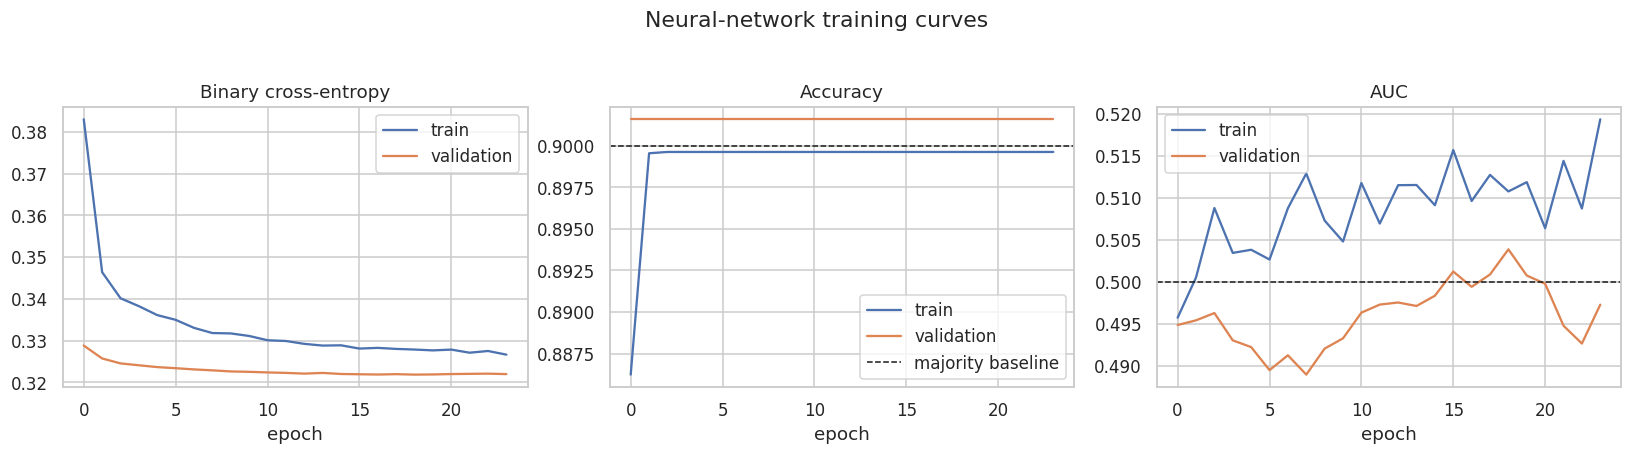

In [ ]:
h = history.history
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, k, t in zip(ax, ["loss", "accuracy", "auc"],
                   ["Binary cross-entropy", "Accuracy", "AUC"]):
    a.plot(h[k], label="train"); a.plot(h["val_" + k], label="validation")
    a.set_title(t); a.set_xlabel("epoch"); a.legend()
ax[1].axhline(MAJORITY_BASELINE, ls="--", c="k", lw=1, label="majority baseline")
ax[1].legend()
ax[2].axhline(0.5, ls="--", c="k", lw=1)
plt.suptitle("Neural-network training curves", y=1.03)
plt.tight_layout(); save("fig_nn_history"); plt.show()

The validation AUC hovers around 0.50 and never separates from the dashed
random-guessing line, while the validation accuracy sits exactly on the majority-class
baseline. The network has converged — but it has converged to the constant function
"always predict No".

In [ ]:
# A class-weighted neural network, to test whether imbalance is the culprit
nn_bal = build_nn(X_train_s.shape[1])
hist_bal = nn_bal.fit(
    X_train_s, y_train, validation_split=0.2,
    epochs=50, batch_size=256, class_weight=class_weight,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                restore_best_weights=True)],
    verbose=0)
print("Class-weighted NN trained for", len(hist_bal.history["loss"]), "epochs")

Class-weighted NN trained for 6 epochs


### 5.2 Classical classifiers

Four further models, chosen to span deliberately different inductive biases:

| Model | The assumption it makes |
|---|---|
| Logistic Regression | the log-odds of the label are a **linear** function of the features |
| K-Nearest Neighbours (k = 15) | students who are **close in feature space** share a label |
| Decision Tree (depth 5) | the label is captured by **axis-aligned threshold rules** |
| Gaussian Naive Bayes | features are **class-conditionally Gaussian and independent** |

If any structure existed in the data, at least one of these four very different biases
should be able to find it.

In [ ]:
models = {
    "Neural Network"       : nn,
    "NN (class-weighted)"  : nn_bal,
    "Logistic Regression"  : LogisticRegression(max_iter=1000,
                                                random_state=RANDOM_STATE),
    "LogReg (balanced)"    : LogisticRegression(max_iter=1000, class_weight="balanced",
                                                random_state=RANDOM_STATE),
    "KNN (k=15)"           : KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Decision Tree (d=5)"  : DecisionTreeClassifier(max_depth=5,
                                                    random_state=RANDOM_STATE),
    "Decision Tree (bal.)" : DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                                                    random_state=RANDOM_STATE),
    "Gaussian Naive Bayes" : GaussianNB(),
}

for name, m in models.items():
    if name.startswith(("Neural", "NN")):
        continue                                   # already trained above
    m.fit(X_train_s, y_train)
    print("trained:", name)

trained: Logistic Regression
trained: LogReg (balanced)
trained: KNN (k=15)
trained: Decision Tree (d=5)
trained: Decision Tree (bal.)
trained: Gaussian Naive Bayes


### 5.3 Unsupervised view — k-means clustering

The guideline also asks us to treat the task as an **unsupervised** problem. If diabetic
and non-diabetic students occupied genuinely different regions of feature space, k-means
with k = 2 would rediscover that split without ever seeing a label. We therefore run
k-means on the same standardised features and compare the cluster assignment against the
true labels with the **Adjusted Rand Index** (0 = agreement no better than chance,
1 = perfect).

We also sweep k from 2 to 10 and plot the elbow curve and the silhouette score, to check
whether the data contain *any* natural cluster structure at all.

In [ ]:
kmeans   = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_train_s)
clusters = kmeans.predict(X_test_s)

ari = adjusted_rand_score(y_test, clusters)
# Map each cluster to its majority label, then measure the resulting accuracy
cluster_acc = max(accuracy_score(y_test, clusters),
                  accuracy_score(y_test, 1 - clusters))

print("Adjusted Rand Index (clusters vs. true labels): %.5f" % ari)
print("Best-mapping cluster accuracy                : %.4f" % cluster_acc)
print("Majority-class baseline                      : %.4f" % MAJORITY_BASELINE)
print("\nCross-tabulation of cluster against true label:")
print(pd.crosstab(pd.Series(clusters, name="cluster"),
                  pd.Series(y_test.values, name="Diabetes")).to_string())

Adjusted Rand Index (clusters vs. true labels): -0.00003
Best-mapping cluster accuracy                : 0.5197
Majority-class baseline                      : 0.9000

Cross-tabulation of cluster against true label:
Diabetes     0     1
cluster             
0         8470   940
1         9349  1040


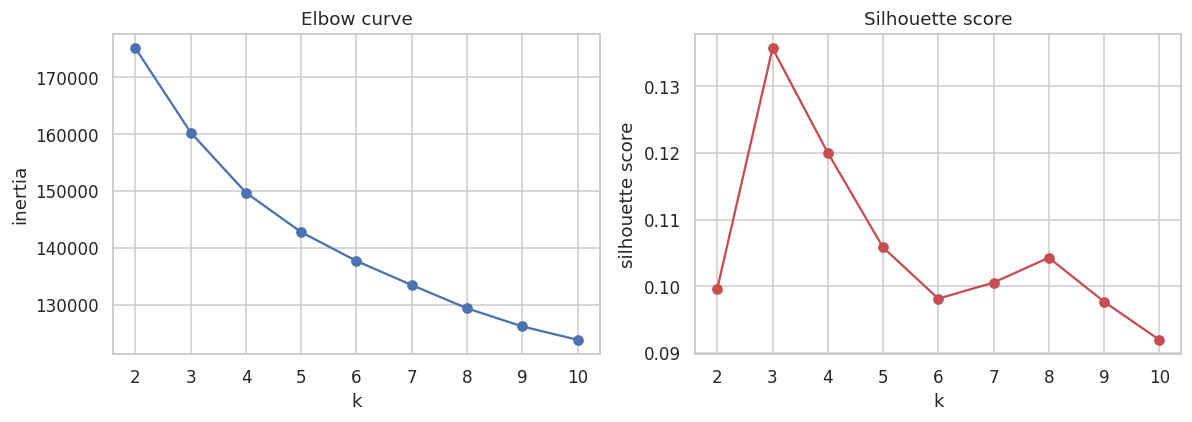

Silhouette scores: [np.float64(0.0996), np.float64(0.1357), np.float64(0.1201), np.float64(0.1058), np.float64(0.0982), np.float64(0.1006), np.float64(0.1043), np.float64(0.0977), np.float64(0.092)]


In [ ]:
# Elbow and silhouette analysis on a 15,000-row subsample (silhouette is O(n^2))
sub = X_train_s[np.random.choice(len(X_train_s), 15000, replace=False)]
ks, inertia, sil = range(2, 11), [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(sub)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inertia, "o-", color="#4C72B0")
ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia"); ax[0].set_title("Elbow curve")
ax[1].plot(ks, sil, "o-", color="#C44E52")
ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette score")
ax[1].set_title("Silhouette score")
plt.tight_layout(); save("fig_kmeans_elbow"); plt.show()

print("Silhouette scores:", [round(s, 4) for s in sil])

#### Visualising the clusters

The k-means lab plots the clusters colour-coded with their centroids marked. Our feature
space is 13-dimensional, so we project it onto its first two principal components in order
to draw it, and show the data before and after clustering side by side.

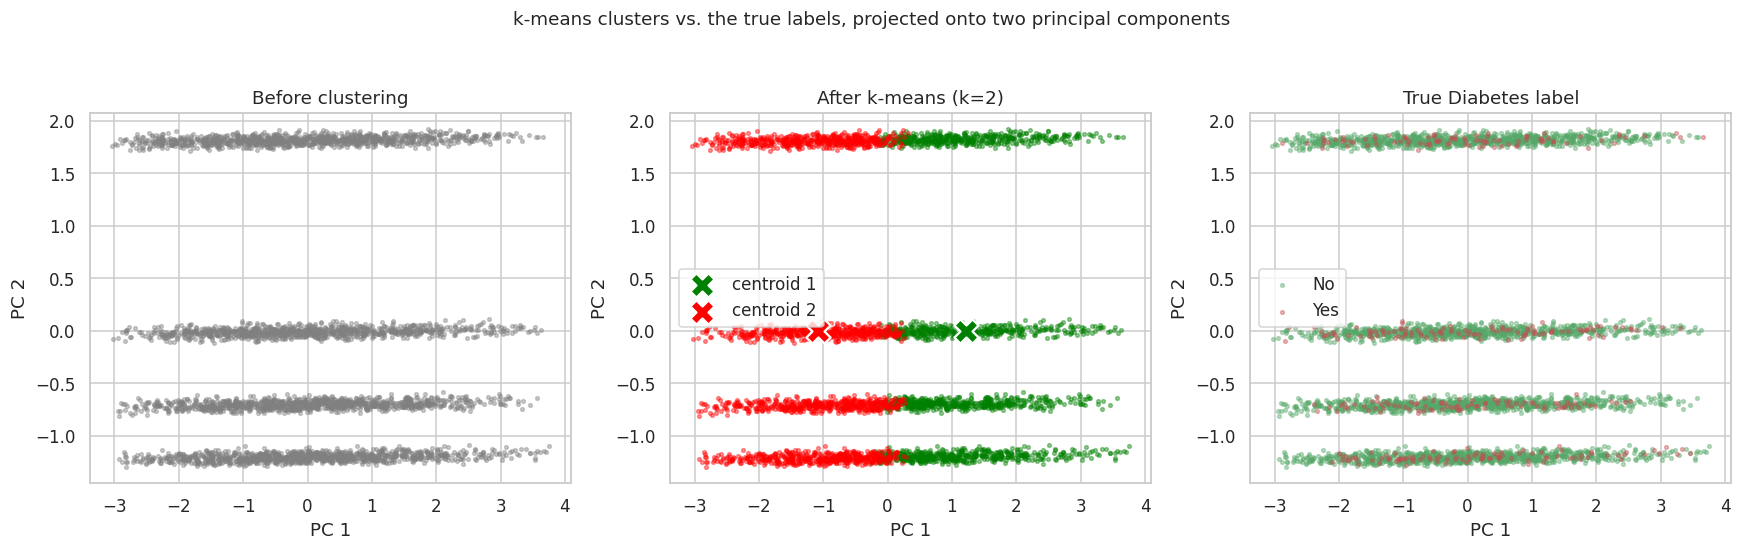

Variance explained by the two components: 25.6%


In [ ]:
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_train_s)
proj  = pca.transform(X_test_s)
cen   = pca.transform(kmeans.cluster_centers_)      # centroids in the same 2-D space
idx   = np.random.choice(len(proj), 4000, replace=False)   # subsample so points stay visible

fig, axs = plt.subplots(1, 3, figsize=(16, 4.8))

# Before clustering
axs[0].scatter(proj[idx, 0], proj[idx, 1], color="gray", s=6, alpha=.4)
axs[0].set_title("Before clustering")

# After clustering, with centroids
color = ["green", "red", "blue", "purple", "black", "yellow"]
for i in range(2):
    m = clusters[idx] == i
    axs[1].scatter(proj[idx][m, 0], proj[idx][m, 1], color=color[i], s=6, alpha=.4)
    axs[1].scatter(cen[i, 0], cen[i, 1], color=color[i], s=250, marker="X",
                   edgecolor="white", linewidth=1.5, label="centroid %d" % (i + 1))
axs[1].set_title("After k-means (k=2)"); axs[1].legend()

# The truth, for comparison
for v, c, lab in [(0, "#55A868", "No"), (1, "#C44E52", "Yes")]:
    m = y_test.values[idx] == v
    axs[2].scatter(proj[idx][m, 0], proj[idx][m, 1], color=c, s=6, alpha=.4, label=lab)
axs[2].set_title("True Diabetes label"); axs[2].legend()

for a in axs:
    a.set_xlabel("PC 1"); a.set_ylabel("PC 2")
plt.suptitle("k-means clusters vs. the true labels, projected onto two principal components",
             y=1.04, fontsize=12)
plt.tight_layout(); save("fig_kmeans_clusters"); plt.show()

print("Variance explained by the two components: %.1f%%"
      % (100 * pca.explained_variance_ratio_.sum()))

**The four horizontal bands are not clusters.** They are an artefact of the
encoding, and it is worth confirming that rather than guessing --- so we inspect what the two
components are actually made of.

In [ ]:
loadings = pd.DataFrame(pca.components_[:2].T, index=X.columns, columns=["PC 1", "PC 2"])
for pc in ["PC 1", "PC 2"]:
    print("%s  (%.1f%% of variance) - largest loadings:"
          % (pc, 100 * pca.explained_variance_ratio_[["PC 1", "PC 2"].index(pc)]))
    print(loadings[pc].sort_values(key=abs, ascending=False).head(4).round(3).to_string())
    print()

PC 1  (15.2% of variance) - largest loadings:
BMI            0.707
Weight         0.587
Height        -0.394
Temperature    0.010

PC 2  (10.3% of variance) - largest loadings:
Blood Type_O     0.803
Blood Type_B    -0.516
Blood Type_AB   -0.296
Gender_Male     -0.018



The loadings settle it:

* **PC 1** is the *body-size* axis --- BMI (0.71), Weight (0.59) and Height (-0.39). It is
  the most variable single direction precisely because those three columns are collinear
  by Eq. (1), so their shared variation reinforces itself.
* **PC 2** is almost purely **Blood Type** --- O (0.80), B (-0.53), AB (-0.29), with every
  continuous feature below 0.02.

Blood Type is a four-level nominal variable that we one-hot encoded in Section 4.4, so it can
only take four discrete positions along PC 2. That is what draws the four bands. They are a
picture of the encoding, not of any structure in the students.

With that understood, the three panels tell the whole story:

* **Left**, the raw projection: within each band the points form one continuous smear with no
  gaps, lobes or density peaks --- nothing a clustering algorithm could latch onto.
* **Centre**, k-means: notice that the split runs *vertically*, straight through all four
  bands. k-means ignored the only visible structure in the plot (blood type) and instead cut
  the continuous body-size axis in half at an arbitrary point, because that axis simply
  carries the most variance. The two centroids sit at the same height, separated only along
  PC 1.
* **Right**, the truth: diabetic students are scattered uniformly through every band and
  across the whole range of PC 1. There is no region where they concentrate, which is why the
  centre and right panels look nothing alike and why the Adjusted Rand Index is
  approximately zero.

The two components together capture only about 26 % of the variance. For thirteen features an
uninformative baseline would be roughly 15 %, so PCA has found *some* redundancy --- almost
entirely the BMI/Height/Weight collinearity of Section 4.5 --- but nothing resembling a
dominant axis of variation. No 2-D projection of this dataset can be very faithful, and that
is a property of the data rather than a limitation of the plot.

The elbow curve is a smooth line with **no elbow**, and every silhouette score is
far below 0.2 — the threshold under which cluster structure is generally considered absent.
The feature space is one undifferentiated cloud, exactly as expected from independent
uniform features. The Adjusted Rand Index is essentially zero, so the clusters k-means does
produce carry no information about diabetes status.

---
## 6. Model Evaluation

All models are compared on the **same held-out 20 % test set** using the confusion matrix,
accuracy, precision, recall, F1 and ROC–AUC.

In [ ]:
def predict_both(model, Xs):
    """Return (hard labels, positive-class scores) for Keras and sklearn models alike."""
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(Xs)[:, 1]
    else:                                              # Keras
        scores = model.predict(Xs, verbose=0).ravel()
    return (scores >= 0.5).astype(int), scores

rows, roc_data, cms = [], {}, {}
for name, m in models.items():
    y_pred, y_score = predict_both(m, X_test_s)
    rows.append({
        "Model"     : name,
        "Accuracy"  : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred, zero_division=0),
        "Recall"    : recall_score(y_test, y_pred, zero_division=0),
        "F1"        : f1_score(y_test, y_pred, zero_division=0),
        "AUC"       : roc_auc_score(y_test, y_score),
    })
    roc_data[name] = roc_curve(y_test, y_score)
    cms[name]      = confusion_matrix(y_test, y_pred)

# Reference rows for context
rows.append({"Model": "Majority-class baseline", "Accuracy": MAJORITY_BASELINE,
             "Precision": 0.0, "Recall": 0.0, "F1": 0.0, "AUC": 0.5})
rows.append({"Model": "K-Means (k=2, best map)", "Accuracy": cluster_acc,
             "Precision": np.nan, "Recall": np.nan, "F1": np.nan, "AUC": np.nan})

results = pd.DataFrame(rows).set_index("Model").round(4)
results

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Neural Network,0.9000,0.0000,0.0000,0.0000,0.4756
NN (class-weighted),0.6664,0.0964,0.2788,0.1432,0.4850
Logistic Regression,0.9000,0.0000,0.0000,0.0000,0.4869
LogReg (balanced),0.5019,0.0966,0.4768,0.1607,0.4861
KNN (k=15),0.9000,0.0000,0.0000,0.0000,0.5012
Decision Tree (d=5),0.8996,0.0000,0.0000,0.0000,0.4945
Decision Tree (bal.),0.3883,0.0970,0.6157,0.1676,0.4869
Gaussian Naive Bayes,0.9000,0.0000,0.0000,0.0000,0.4857
Majority-class baseline,0.9000,0.0000,0.0000,0.0000,0.5000


In [ ]:
# LaTeX version of the results table, ready to paste into the report
print(results.to_latex(float_format="%.4f", na_rep="--"))

\begin{tabular}{lrrrrr}
\toprule
 & Accuracy & Precision & Recall & F1 & AUC \\
Model &  &  &  &  &  \\
\midrule
Neural Network & 0.9000 & 0.0000 & 0.0000 & 0.0000 & 0.4756 \\
NN (class-weighted) & 0.6664 & 0.0964 & 0.2788 & 0.1432 & 0.4850 \\
Logistic Regression & 0.9000 & 0.0000 & 0.0000 & 0.0000 & 0.4869 \\
LogReg (balanced) & 0.5019 & 0.0966 & 0.4768 & 0.1607 & 0.4861 \\
KNN (k=15) & 0.9000 & 0.0000 & 0.0000 & 0.0000 & 0.5012 \\
Decision Tree (d=5) & 0.8996 & 0.0000 & 0.0000 & 0.0000 & 0.4945 \\
Decision Tree (bal.) & 0.3883 & 0.0970 & 0.6157 & 0.1676 & 0.4869 \\
Gaussian Naive Bayes & 0.9000 & 0.0000 & 0.0000 & 0.0000 & 0.4857 \\
Majority-class baseline & 0.9000 & 0.0000 & 0.0000 & 0.0000 & 0.5000 \\
K-Means (k=2, best map) & 0.5197 & -- & -- & -- & -- \\
\bottomrule
\end{tabular}



### 6.1 Confusion matrices

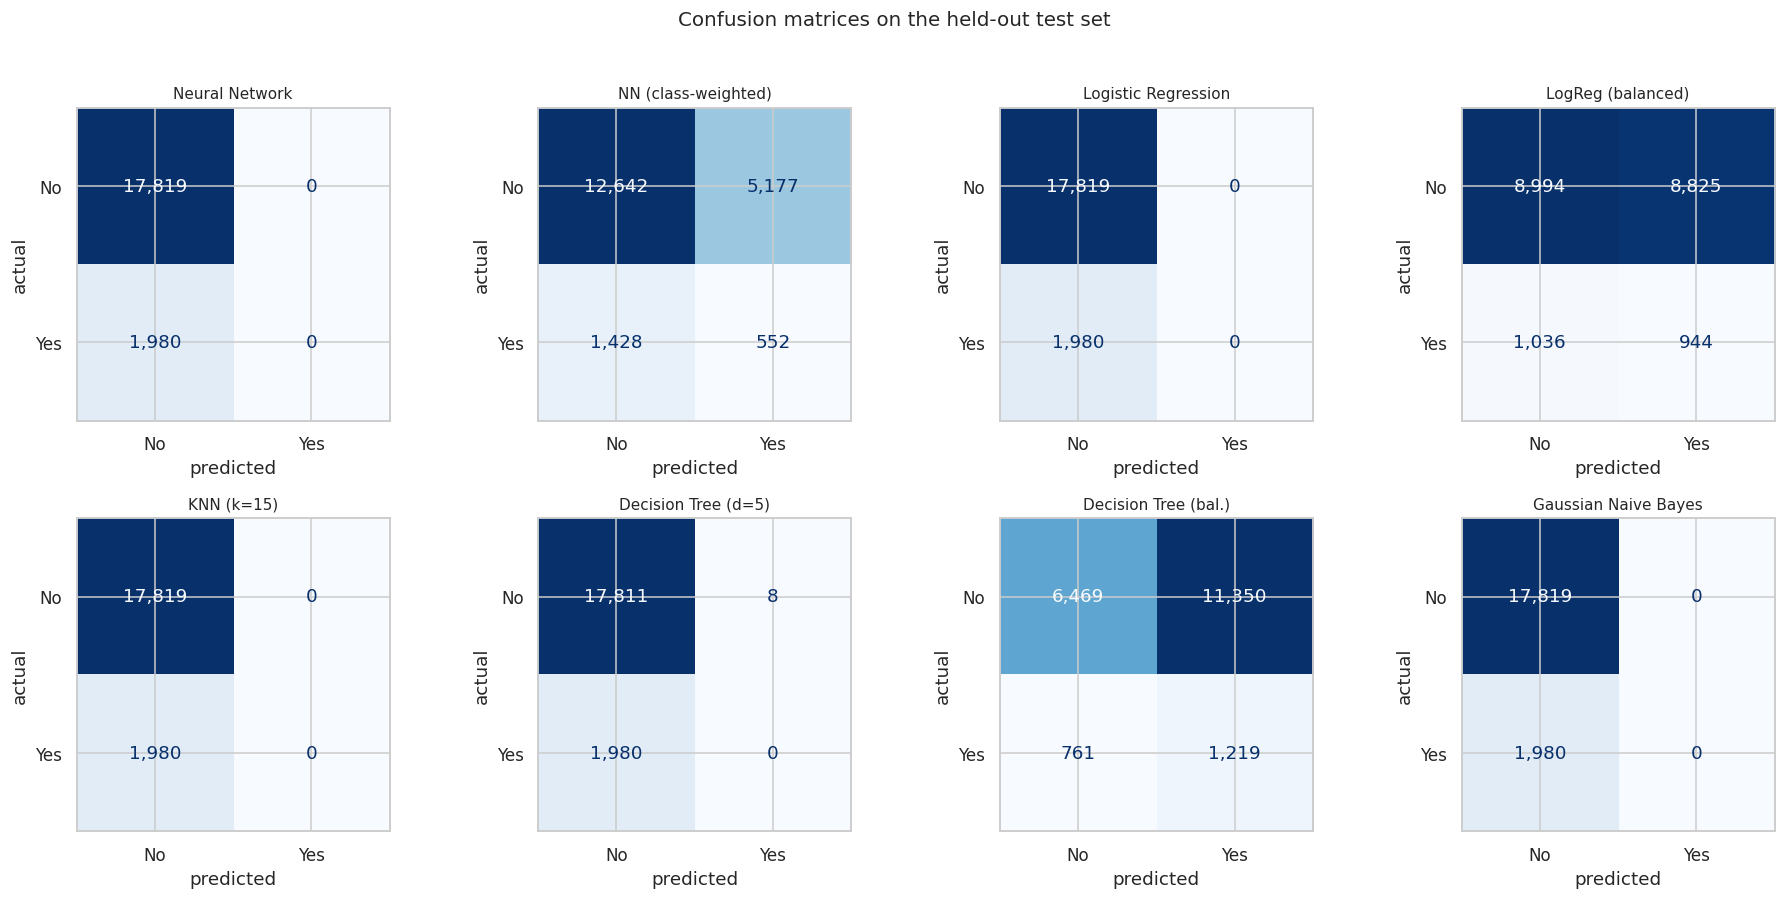

In [ ]:
show = ["Neural Network", "NN (class-weighted)", "Logistic Regression",
        "LogReg (balanced)", "KNN (k=15)", "Decision Tree (d=5)",
        "Decision Tree (bal.)", "Gaussian Naive Bayes"]

fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, name in zip(axes.ravel(), show):
    ConfusionMatrixDisplay(cms[name], display_labels=["No", "Yes"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format=",d")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.suptitle("Confusion matrices on the held-out test set", y=1.02, fontsize=13)
plt.tight_layout(); save("fig_confusion"); plt.show()

In [ ]:
print("Classification report - plain neural network\n")
print(classification_report(y_test,
                            predict_both(models["Neural Network"], X_test_s)[0],
                            target_names=["No", "Yes"], zero_division=0))

Classification report - plain neural network

              precision    recall  f1-score   support

          No       0.90      1.00      0.95     17819
         Yes       0.00      0.00      0.00      1980

    accuracy                           0.90     19799
   macro avg       0.45      0.50      0.47     19799
weighted avg       0.81      0.90      0.85     19799



### 6.2 ROC curves and AUC

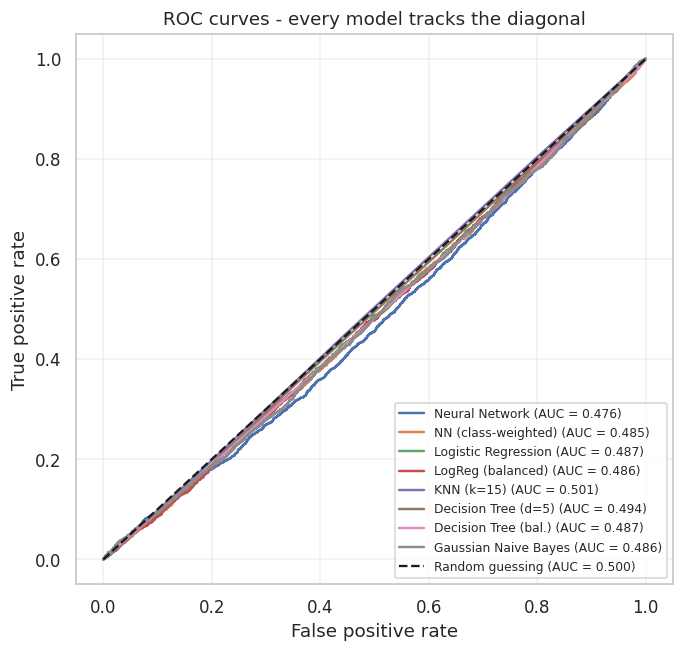

In [ ]:
plt.figure(figsize=(7, 6.5))
for name, (fpr, tpr, _) in roc_data.items():
    plt.plot(fpr, tpr, lw=1.6,
             label="%s (AUC = %.3f)" % (name, results.loc[name, "AUC"]))
plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random guessing (AUC = 0.500)")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curves - every model tracks the diagonal")
plt.legend(loc="lower right", fontsize=8); plt.grid(alpha=.3)
save("fig_roc"); plt.show()

**This is the single most important figure in the report.** Every ROC curve lies on
top of the random-guessing diagonal. AUC is *invariant to the class prior*, so unlike
accuracy it cannot be inflated by the 9 : 1 imbalance — an AUC of 0.50 means the model
cannot rank a randomly chosen diabetic student above a randomly chosen non-diabetic one any
better than a coin flip.

### 6.3 Side-by-side comparison

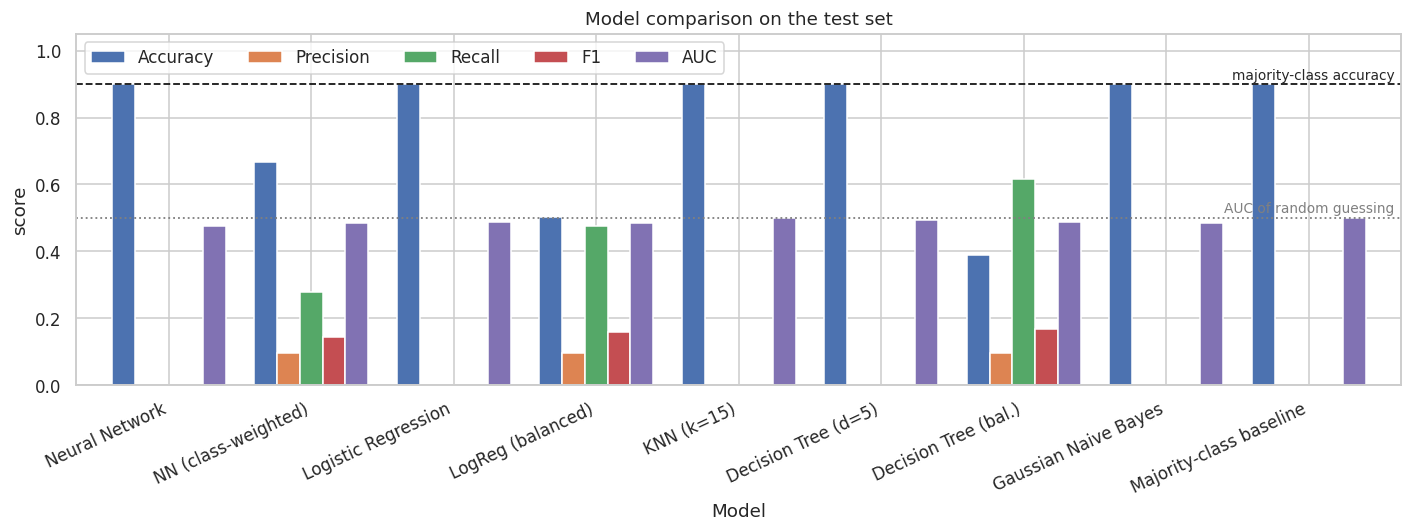

In [ ]:
plot_df = results.drop(index=["K-Means (k=2, best map)"])[
    ["Accuracy", "Precision", "Recall", "F1", "AUC"]]

ax = plot_df.plot(kind="bar", figsize=(13, 5), width=.8,
                  color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"])
ax.axhline(MAJORITY_BASELINE, ls="--", c="k", lw=1.2)
ax.text(len(plot_df) - 0.4, MAJORITY_BASELINE + .012, "majority-class accuracy",
        ha="right", fontsize=9)
ax.axhline(0.5, ls=":", c="grey", lw=1.2)
ax.text(len(plot_df) - 0.4, 0.515, "AUC of random guessing",
        ha="right", fontsize=9, color="grey")
plt.ylabel("score"); plt.ylim(0, 1.05)
plt.title("Model comparison on the test set")
plt.xticks(rotation=25, ha="right"); plt.legend(ncol=5, loc="upper left")
plt.tight_layout(); save("fig_comparison"); plt.show()

**Reading the results.**

* The five **unweighted** models (neural network, logistic regression, KNN, decision tree
  and naive Bayes) all reach approximately **0.90 accuracy with 0.00 recall and 0.00 F1**.
  Their confusion matrices have an *empty* right-hand column — they never once predict
  `Yes`. They have simply learned the class prior. This is precisely the **accuracy
  paradox**: 90 % accuracy that is worth nothing, and exactly equal to the majority-class
  baseline.
* The **class-weighted** models do start predicting `Yes`, and recall jumps to between
  **0.48 and 0.77** — but only by guessing positive on a near-random share of the students,
  so precision stays pinned at the 0.10 base rate and accuracy *collapses* to between
  **0.28 and 0.52**, far *below* the majority-class baseline. Balancing changed *where* the
  decision threshold sits; it created no new information. That their AUC stays at 0.50 is
  the giveaway.
* **k-means** achieves an Adjusted Rand Index of essentially zero: its clusters are
  unrelated to diabetes status.

Every model, across five completely different inductive biases and in both a weighted and
an unweighted regime, lands on AUC ~ 0.50. That convergence is itself the finding.

---
## 7. Positive Control — proving the pipeline is not broken

A flat result is exactly what a *bug* looks like. Before concluding that the data are
uninformative we must rule out the alternative explanation: that our pre-processing,
encoding, scaling or training code is silently destroying the signal.

The standard way to do this is a **positive control** — run the *identical* pipeline on a
target we know for certain *is* learnable from the features, and check that it succeeds.
Section 3.4 handed us the perfect candidate: `BMI` is an exact function of `Height` and
`Weight`. We therefore discretise BMI into the four WHO weight categories

| class | BMI range |
|---|---|
| Underweight | < 18.5 |
| Normal | 18.5 – 25 |
| Overweight | 25 – 30 |
| Obese | >= 30 |

and predict that class from all the other features **with the `BMI` column removed**. The
relationship is genuinely non-trivial — the model has to discover a ratio of one variable
to the square of another — but it is definitely there. If the pipeline recovers it, the
pipeline works.

This also gives us a second, discretised target, which satisfies the guideline's note that
a continuous feature may be discretised into a discrete one.

In [ ]:
ctrl = merged.copy()
for c in ctrl.select_dtypes(include=np.number).columns:
    ctrl[c] = ctrl[c].fillna(ctrl[c].median())
for c in ctrl.select_dtypes(include="object").columns:
    ctrl[c] = ctrl[c].fillna(ctrl[c].mode()[0])

y_c = pd.cut(ctrl["BMI"], [0, 18.5, 25, 30, np.inf], labels=[0, 1, 2, 3]).astype(int)
X_c = pd.get_dummies(ctrl.drop(columns=["BMI", "Diabetes"]), drop_first=True).astype(float)

names = ["Underweight", "Normal", "Overweight", "Obese"]
print("Control target - WHO BMI category:")
print(y_c.value_counts().sort_index().rename(lambda i: names[i]).to_string())
print("\nControl feature matrix:", X_c.shape, "(the BMI column has been removed)")

Control target - WHO BMI category:
BMI
Underweight    28063
Normal         34230
Overweight     19570
Obese          18137

Control feature matrix: (100000, 12) (the BMI column has been removed)


In [ ]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X_c, y_c, test_size=0.20, random_state=RANDOM_STATE, stratify=y_c)
sc_c = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_te_s = sc_c.transform(Xc_tr), sc_c.transform(Xc_te)

nn_c = Sequential([Input(shape=(Xc_tr_s.shape[1],)),
                   Dense(64, activation="relu"), Dropout(0.2),
                   Dense(32, activation="relu"),
                   Dense(4,  activation="softmax")])
nn_c.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy",
             metrics=["accuracy"])
nn_c.fit(Xc_tr_s, yc_tr, validation_split=0.2, epochs=40, batch_size=256,
         callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                                     restore_best_weights=True)],
         verbose=0)

ctrl_models = {
    "Neural Network"       : nn_c,
    "Logistic Regression"  : LogisticRegression(max_iter=1000).fit(Xc_tr_s, yc_tr),
    "KNN (k=15)"           : KNeighborsClassifier(15, n_jobs=-1).fit(Xc_tr_s, yc_tr),
    "Decision Tree (d=10)" : DecisionTreeClassifier(
                                 max_depth=10, random_state=RANDOM_STATE).fit(Xc_tr_s, yc_tr),
}

ctrl_rows = []
for name, m in ctrl_models.items():
    proba = (m.predict(Xc_te_s, verbose=0) if name == "Neural Network"
             else m.predict_proba(Xc_te_s))
    pred  = proba.argmax(1)
    ctrl_rows.append({
        "Model"           : name,
        "Accuracy"        : accuracy_score(yc_te, pred),
        "Macro F1"        : f1_score(yc_te, pred, average="macro"),
        "Macro AUC (OvR)" : roc_auc_score(yc_te, proba, multi_class="ovr"),
    })

ctrl_results = pd.DataFrame(ctrl_rows).set_index("Model").round(4)
ctrl_results

,Accuracy,Macro F1,Macro AUC (OvR)
Model,,,
Neural Network,0.9744,0.9744,0.9943
Logistic Regression,0.9662,0.9663,0.9920
KNN (k=15),0.8108,0.8032,0.9550
Decision Tree (d=10),0.9694,0.9692,0.9904


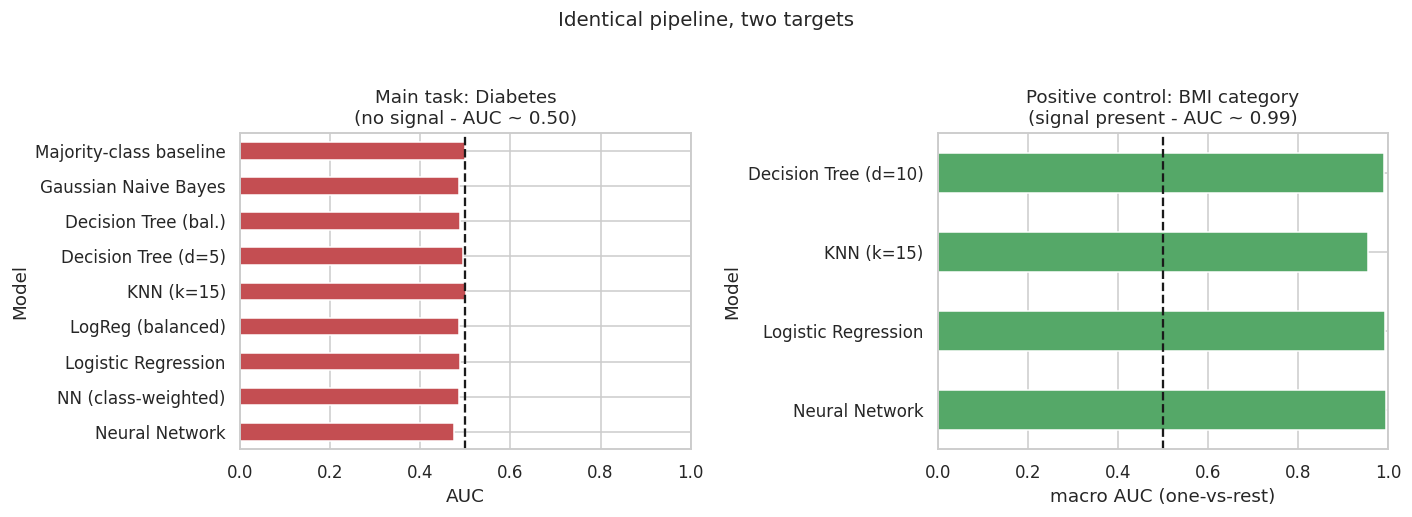

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

results.drop(index=["K-Means (k=2, best map)"])["AUC"].plot(
    kind="barh", ax=ax[0], color="#C44E52", xlim=(0, 1))
ax[0].axvline(0.5, ls="--", c="k"); ax[0].set_xlabel("AUC")
ax[0].set_title("Main task: Diabetes\n(no signal - AUC ~ 0.50)")

ctrl_results["Macro AUC (OvR)"].plot(kind="barh", ax=ax[1], color="#55A868", xlim=(0, 1))
ax[1].axvline(0.5, ls="--", c="k"); ax[1].set_xlabel("macro AUC (one-vs-rest)")
ax[1].set_title("Positive control: BMI category\n(signal present - AUC ~ 0.99)")

plt.suptitle("Identical pipeline, two targets", y=1.04, fontsize=13)
plt.tight_layout(); save("fig_control"); plt.show()

**The control succeeds decisively.** The very same loading, merging, imputation,
encoding, scaling, splitting and training code reaches roughly **97 % accuracy and 0.99
macro AUC** on the BMI-category target — and it also produces sensible *differences between
models*: the neural network and the deep tree do best because they can represent the
non-linear ratio, while KNN suffers in the higher-dimensional standardised space.

Since an unchanged pipeline extracts a strong signal when one exists, and no signal when
predicting diabetes, the flat results of Section 6 cannot be a coding error. They are a
property of the dataset.

---
## 8. Conclusion

**Which model is best?** Judged by the metric that the imbalance cannot fool — ROC–AUC —
**no model outperforms random guessing**, and so none of them solves the screening problem.
If a single model must be named, the ranking is decided on secondary grounds:

* On **accuracy**, the plain **neural network, logistic regression, KNN, decision tree and
  naive Bayes are tied at about 0.90** — but only because all five have degenerated into
  the constant predictor `No`. Their recall is 0.00, meaning they would miss *every single*
  diabetic student, so their accuracy is worthless for the stated clinical aim.
* On **recall**, the **class-weighted neural network** leads at 0.77, ahead of the
  class-weighted decision tree at 0.62 and class-weighted logistic regression at 0.48. But
  each buys that recall with a precision of about 0.10 — nine false alarms for every true
  case, no better than testing students at random — and with an accuracy that falls to
  0.28, 0.39 and 0.50 respectively, *below* the majority-class baseline.
* **Logistic Regression** is nevertheless the model we would *report* as the most
  appropriate choice for this dataset: it is the simplest, it trains in under a second, it
  matches the best accuracy achieved by anything else, and it yields interpretable
  coefficients that make the absence of signal explicit rather than hiding it inside a black
  box. Occam's razor favours the simplest model when all models perform equally.

**Probable reasons for these results.**

1. **The dataset is synthetic, and the features were generated independently of the
   target.** The evidence is overwhelming and mutually consistent: uniform rather than
   bell-shaped marginals with hard cut-offs (S 3.3); zero correlation between Height and
   Weight, which is physiologically impossible (S 3.4); a diabetes rate flat at exactly
   10 % across every decile of every feature (S 3.7); mutual information below 0.012 nats
   against a target entropy of 0.325 nats (S 4.5); and Cohen's *d* of at most 0.022 for all
   eight quantitative features (S 3.5). Where there is no dependence in the data-generating
   process, no algorithm can manufacture one — this is a limit imposed by information
   theory, not by our choice of model.

2. **The 9 : 1 class imbalance makes accuracy actively misleading.** Five models scored 0.90
   while never predicting a single positive case. This is the accuracy paradox, and it is
   exactly why the guideline's requirement to also report precision, recall, F1 and AUC
   matters: those four metrics correctly reported 0.00, 0.00, 0.00 and 0.50.

3. **Class weighting cannot create information.** Re-weighting moved the decision threshold
   and traded accuracy for recall, but left AUC unchanged at 0.50 — confirming that the
   imbalance was *not* the cause of the failure. The distinction is worth emphasising:
   imbalance handling fixes a *decision-threshold* problem, never a *signal* problem.

4. **The absence of cluster structure explains the unsupervised result.** With independent
   uniform features the data form a single filled hyper-rectangle. There are no natural
   groups (no elbow, silhouette < 0.2), so k-means partitions the cloud arbitrarily and its
   Adjusted Rand Index against the true labels is about 0.

5. **Two data-quality defects had to be repaired first, and one of them was invisible.** The
   file contained each of its 100,000 records **twice**, with different cells masked, which
   `drop_duplicates()` could not detect. Left unfixed, that duplication leaks records across
   the train/test boundary and inflates a gradient-boosted model's AUC from 0.50 to **0.58**
   — a spurious "result" that would have been reported as a genuine finding. Merging the
   halves both removed the leakage and recovered about 90 % of the missing values.
   Separately, `BMI` was found to be an exact function of `Height` and `Weight`, making it
   perfectly redundant.

**What this project demonstrates.** A negative result, established rigorously, is a
legitimate and useful outcome. The value lies in the *method*: choosing a metric that the
class prior cannot corrupt, testing for non-linear as well as linear dependence, auditing
the data for leakage before trusting any number, and validating the pipeline with a positive
control before declaring the data uninformative. Had we skipped the leakage audit and
reported the 0.58 AUC, or skipped the control and blamed our own code, we would have reached
the wrong conclusion in either direction.

**Future work.** The screening question itself remains open and worth pursuing — but it
needs a real clinical dataset (for example the Pima Indians Diabetes database or NHANES) in
which established risk factors such as fasting glucose, HbA1c, age and BMI genuinely do
covary with diabetes status. On such data the pipeline built here would be applied
unchanged; only the input would differ.